# Chapter 2. Distribution Transport Before Flow Matching

**TL;DR** — Expands the Chapter 2 distribution-transport experiments cell by cell before Flow Matching. The reader finishes with the EB coupling, path-construction, energy-proxy, and solver-in-loop proxy figures and CSV diagnostics used by the paper.

**Prerequisites** - none. This is the entry point.

**Outputs**
- `figures/ch02/fig02_02a_static_ot_independent_endpoint_coupling.png`
- `figures/ch02/fig02_02a_static_ot_independent_endpoint_coupling.svg`
- `figures/ch02/fig02_02b_static_ot_sinkhorn_endpoint_coupling.png`
- `figures/ch02/fig02_02b_static_ot_sinkhorn_endpoint_coupling.svg`
- `figures/ch02/fig02_02c_static_ot_transport_plan_heatmap.png`
- `figures/ch02/fig02_02c_static_ot_transport_plan_heatmap.svg`
- `figures/ch02/fig02_02d_static_ot_epsilon_sensitivity.png`
- `figures/ch02/fig02_02d_static_ot_epsilon_sensitivity.svg`
- `figures/ch02/fig02_03a_endpoint_coupling_only.png`
- `figures/ch02/fig02_03a_endpoint_coupling_only.svg`
- `figures/ch02/fig02_03b_straight_bridges.png`
- `figures/ch02/fig02_03b_straight_bridges.svg`
- `figures/ch02/fig02_03c_curved_bridges.png`
- `figures/ch02/fig02_03c_curved_bridges.svg`
- `figures/ch02/fig02_03d_stochastic_bridge_samples.png`
- `figures/ch02/fig02_03d_stochastic_bridge_samples.svg`
- `figures/ch02/fig02_04a_fixed_endpoint_pairs.png`
- `figures/ch02/fig02_04a_fixed_endpoint_pairs.svg`
- `figures/ch02/fig02_04b_path_construction_fixed_endpoints.png`
- `figures/ch02/fig02_04b_path_construction_fixed_endpoints.svg`
- `figures/ch02/fig02_04c_pc20_action_proxy.png`
- `figures/ch02/fig02_04c_pc20_action_proxy.svg`
- `outputs/ch02/table02_01_coupling_diagnostics.csv`
- `outputs/ch02/table02_optional_ot_cost_sensitivity.csv`
- `outputs/ch02/table02_02_path_diagnostics.csv`
- `outputs/ch02/table02_03_dynamic_ot_energy_proxy.csv`
- `outputs/ch02/table02_04_cnf_training_bottleneck.csv`
- `outputs/ch02/table02_04_training_cost_proxy.csv`

**Runtime** - `QUICK_MODE` is on by default and keeps the EB subset, OT sensitivity, and CNF proxy small enough for tutorial use; there is no separate `SMOKE_MODE` knob in this notebook. On CPU, expect a short tutorial run, with the CNF proxy section usually the slowest part.

**Key parameters**
- `seed = 42` controls subsampling, endpoint-pair sampling, stochastic bridges, and the CNF proxy.
- `quick_mode = True` is the default tutorial-size control.
- `cost_space = "PC-20"`; PHATE is display-only for selected cells.
- `static_ot_main_epsilon = 0.05` with an epsilon sensitivity grid.
- CNF proxy knobs: `batch_size = 256`, `n_steps = 100` in quick mode, `n_solver_steps = 16`, and `eval_solver_steps = 32`.

## 1. Setup

This section fixes paths, random seed, plotting defaults, and the `quick_mode` setting used by the cloud reproducibility run. All figures are written to `figures/ch02`; all tables and the run summary are written to `outputs/ch02`.


In [1]:
import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/mplconfig_ch02")
os.environ.setdefault("NUMBA_CACHE_DIR", "/tmp/numba_cache_ch02")

import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

started = time.perf_counter()
quick_mode = True
seed = 42
rng = np.random.default_rng(seed)

import sys

ROOT_HINT = Path.cwd().resolve()
if not (ROOT_HINT / "src").is_dir():
    ROOT_HINT = ROOT_HINT.parent
if str(ROOT_HINT) not in sys.path:
    sys.path.insert(0, str(ROOT_HINT))

from src.tutorial_init import apply_tutorial_plot_style, bootstrap, make_save_and_show

boot = bootstrap(chapter="ch02", seed=seed, quick_mode=quick_mode)
PROJECT_ROOT = boot.project_root
FIG_DIR = boot.fig_dir
OUT_DIR = boot.out_dir
DEVICE = boot.device
fig_dir = FIG_DIR
out_dir = OUT_DIR
paper_root = PROJECT_ROOT

from src.data.loading import load_eb_timecourse_for_ch03
from src.evaluation.metrics import coupling_l1_distance, mmd_rbf
from src.core.models import VelocityMLP
from src.core.ot import (
    compute_ot_coupling_from_cost,
    coupling_diagnostics,
    independent_coupling,
    median_positive_scale,
    pairwise_squared_distances,
    sample_pair_indices_from_coupling,
)
from src.core.paths import curved_path, linear_path
from src.data.toy import make_y_branching_snapshots
from src.utils import ensure_dir, set_seed

eb_path = PROJECT_ROOT / "data" / "trajectorynet_eb" / "eb_velocity_v5.npz"

print("Project root resolved")
print(f"quick_mode={quick_mode}, seed={seed}")
print(f"fig_dir={fig_dir.relative_to(PROJECT_ROOT)}")
print(f"out_dir={out_dir.relative_to(PROJECT_ROOT)}")


project_root=..
seed=42
quick_mode=True
fig_dir=figures/ch02
out_dir=outputs/ch02
device=cuda
Project root resolved
quick_mode=True, seed=42
fig_dir=figures/ch02
out_dir=outputs/ch02


In [2]:
import matplotlib
matplotlib.use("Agg", force=True)
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D
import matplotlib.patches as patches
from IPython.display import Image, display

apply_tutorial_plot_style()

source_time = "1"
target_time = "2"
n_source_ot = 250
n_target_ot = 250
max_cells_per_time = 900
cost_space = "PC-20"
visualization_space = "PHATE"
static_ot_main_epsilon = 0.05
sinkhorn_epsilons = [0.001, 0.01, 0.05, 0.1, 1.0, 5.0]

print(
    f"Chapter 2 setup: {source_time}->{target_time}, cost={cost_space}, "
    f"display={visualization_space}, OT cells={n_source_ot}x{n_target_ot}."
)


Chapter 2 setup: 1->2, cost=PC-20, display=PHATE, OT cells=250x250.


In [3]:
from src.visualization.transport import (
    action_per_pair_pc,
    brownian_bridge_trajectories,
    coupling_diagnostic_row,
    display_path,
    draw_arrows,
    draw_endpoint_cloud,
    draw_fixed_endpoint_pairs_panel,
    energy_and_length_pc,
    euler_integrate_torch,
    path_stats,
    sample_gaussian_mixture_torch,
    save_ch02_table,
    save_fig_both,
    show_saved_png,
    sorted_time_labels,
    subsample_indices,
    table_preview,
    torch_mmd_rbf,
)

def save_ch02_figure(fig, fig_dir, name, *, write_pdf=False):
    return save_fig_both(fig, fig_dir, name, paper_root)


save_and_show = make_save_and_show(fig_dir, write_pdf=False, save_fn=save_ch02_figure)


## 2. Load EB Data And Representation Roles

This experiment uses `data/trajectorynet_eb/eb_velocity_v5.npz`. The representation roles are fixed before any transport calculation: `X_pc20` from `pcs` is the Euclidean space for OT costs and PC-20 action proxies, `X_phate` from `phate` is only for 2D display, and `time_labels` supplies the empirical snapshot index. The reader should check that the cost and display spaces stay separate throughout the chapter.


In [4]:
eb = load_eb_timecourse_for_ch03(
    path=eb_path,
    cost_embedding="pcs",
    plot_embedding="phate",
    n_cost_dims=20,
    max_cells_per_time=max_cells_per_time,
    seed=seed,
)

X_pc20 = np.asarray(eb["X_cost"], dtype=float)
X_phate = np.asarray(eb["X_plot"], dtype=float)
time_labels = eb["time"].astype(str)
timepoints = sorted_time_labels(time_labels)

print(f"Loaded EB cells after per-time cap: {X_pc20.shape[0]}")
print(f"Cost matrix source: {eb_path.relative_to(PROJECT_ROOT)}")
print(f"Timepoints: {timepoints}")
eb["full_counts_by_time"].head()


Loaded EB cells after per-time cap: 4500
Cost matrix source: data/trajectorynet_eb/eb_velocity_v5.npz
Timepoints: ['0', '1', '2', '3', '4']


,source,cost_embedding,plot_embedding,n_cost_dims,time,n_cells
0,/import/macyang_home4/xmabs/flow_matching_for_...,pcs,phate,20,0,2381
1,/import/macyang_home4/xmabs/flow_matching_for_...,pcs,phate,20,1,4163
2,/import/macyang_home4/xmabs/flow_matching_for_...,pcs,phate,20,2,3278
3,/import/macyang_home4/xmabs/flow_matching_for_...,pcs,phate,20,3,3665
4,/import/macyang_home4/xmabs/flow_matching_for_...,pcs,phate,20,4,3332


In [5]:
print("Representation roles:")
print(f"- X_pc20: source_key='pcs', cost/action space, shape={X_pc20.shape}")
print(f"- X_phate: source_key='phate', display-only space, shape={X_phate.shape}")
print(f"- time_labels: empirical snapshot labels, shape={time_labels.shape}")


Representation roles:
- X_pc20: source_key='pcs', cost/action space, shape=(4500, 20)
- X_phate: source_key='phate', display-only space, shape=(4500, 2)
- time_labels: empirical snapshot labels, shape=(4500,)


## 3. Static OT On EB Snapshots

Question: if we only observe two EB snapshot distributions at source time `1` and target time `2`, how different is an independent endpoint relation from a cost-aware OT endpoint relation?

This section supports Figure 2.2 and Table 2.1. We cap each timepoint at 900 cells during loading, then use 250 source cells and 250 target cells for OT. Costs are squared distances in PC-20; PHATE is used only to draw endpoint clouds and arrows. The number to watch is the expected PC-20 cost gap between the independent coupling and Sinkhorn OT.


In [6]:
idx0_all = np.flatnonzero(time_labels == source_time)
idx1_all = np.flatnonzero(time_labels == target_time)
if len(idx0_all) == 0 or len(idx1_all) == 0:
    raise ValueError(f"EB source/target times {source_time}->{target_time} were not found.")

idx0 = subsample_indices(idx0_all, n_source_ot, rng)
idx1 = subsample_indices(idx1_all, n_target_ot, rng)

X0_cost = X_pc20[idx0]
X1_cost = X_pc20[idx1]
X0_plot = X_phate[idx0]
X1_plot = X_phate[idx1]

pd.DataFrame(
    [
        {"time": source_time, "available_after_cap": len(idx0_all), "used_for_ot": len(idx0)},
        {"time": target_time, "available_after_cap": len(idx1_all), "used_for_ot": len(idx1)},
    ]
)


,time,available_after_cap,used_for_ot
0,1,900,250
1,2,900,250


In [7]:
C_raw = pairwise_squared_distances(X0_cost, X1_cost)
cost_scale = median_positive_scale(C_raw)
C_norm = C_raw / max(cost_scale, 1e-12)

print(f"cost_space={cost_space}; C_raw.shape={C_raw.shape}; cost_scale={cost_scale:.3f}")
print(f"C_raw min={C_raw.min():.2f}, median={np.median(C_raw):.2f}, max={C_raw.max():.2f}")


cost_space=PC-20; C_raw.shape=(250, 250); cost_scale=252.759
C_raw min=16.41, median=252.76, max=1385.15


In [8]:
pi_ind = independent_coupling(len(X0_cost), len(X1_cost))
plans = {}
sinkhorn_infos = {}
coupling_rows = [
    coupling_diagnostic_row("independent", None, pi_ind, C_raw, C_norm, None, cost_scale)
]

for epsilon in sinkhorn_epsilons:
    pi, info = compute_ot_coupling_from_cost(
        C_norm,
        epsilon=float(epsilon),
        return_info=True,
        num_iter_max=5000,
        stop_thr=1e-9,
    )
    plans[float(epsilon)] = pi
    sinkhorn_infos[float(epsilon)] = info
    coupling_rows.append(coupling_diagnostic_row("sinkhorn_ot", epsilon, pi, C_raw, C_norm, info, cost_scale))

pi_main = plans[static_ot_main_epsilon]
coupling_table = pd.DataFrame(coupling_rows)
coupling_table


,method,epsilon,expected_cost_raw,expected_cost_normalized,entropy,effective_support,row_l1_error,col_l1_error,sinkhorn_converged,sinkhorn_n_iter,sinkhorn_backend,cost_scale
0,independent,NaN,299.604267,1.185334,11.042922,62500.000000,6.505213e-16,1.951564e-15,NaN,NaN,independent,252.759349
1,sinkhorn_ot,0.001,182.493993,0.722007,6.466120,642.984328,1.198533e-04,1.092876e-16,False,5000.0,scaling_fallback,252.759349
2,sinkhorn_ot,0.010,147.956585,0.585365,6.349275,572.078003,1.170938e-16,6.034569e-06,False,4999.0,pot,252.759349
3,sinkhorn_ot,0.050,161.363085,0.638406,8.256609,3853.005684,1.509209e-16,1.401640e-09,True,190.0,pot,252.759349
4,sinkhorn_ot,0.100,182.410027,0.721675,9.415359,12275.478591,1.084202e-16,5.979862e-10,True,60.0,pot,252.759349
5,sinkhorn_ot,1.000,277.714295,1.098730,10.999203,59826.430303,1.066855e-16,3.868433e-16,True,10.0,pot,252.759349
6,sinkhorn_ot,5.000,295.370632,1.168584,11.041239,62394.880953,6.418477e-17,3.642919e-16,True,10.0,pot,252.759349


In [9]:
table02_01_path = save_ch02_table(coupling_table, out_dir, "table02_01_coupling_diagnostics.csv", paper_root)
table_preview(coupling_table, columns=["method", "epsilon", "expected_cost_raw", "effective_support", "sinkhorn_converged"], n=8)


,method,epsilon,expected_cost_raw,effective_support,sinkhorn_converged
0,independent,NaN,299.604267,62500.000000,NaN
1,sinkhorn_ot,0.001,182.493993,642.984328,False
2,sinkhorn_ot,0.010,147.956585,572.078003,False
3,sinkhorn_ot,0.050,161.363085,3853.005684,True
4,sinkhorn_ot,0.100,182.410027,12275.478591,True
5,sinkhorn_ot,1.000,277.714295,59826.430303,True
6,sinkhorn_ot,5.000,295.370632,62394.880953,True


In [10]:
i0_ind = rng.integers(0, len(X0_plot), size=32)
i1_ind = rng.integers(0, len(X1_plot), size=32)
i0_ot, i1_ot = sample_pair_indices_from_coupling(pi_main, batch_size=42, seed=seed + 10)
sampled_endpoint_pairs = pd.DataFrame(
    {
        "source_local_index": i0_ot,
        "target_local_index": i1_ot,
        "source_global_index": idx0[i0_ot],
        "target_global_index": idx1[i1_ot],
        "coupling": "sinkhorn_epsilon_0.05",
    }
)
sampled_endpoint_pairs.head()


,source_local_index,target_local_index,source_global_index,target_global_index,coupling
0,153,249,1427,2697,sinkhorn_epsilon_0.05
1,143,119,1404,2268,sinkhorn_epsilon_0.05
2,129,231,1358,2628,sinkhorn_epsilon_0.05
3,1,160,917,2400,sinkhorn_epsilon_0.05
4,137,211,1385,2560,sinkhorn_epsilon_0.05


The static OT diagnostics are saved one panel at a time. Each saved panel is displayed immediately below the code that creates it, which keeps the endpoint clouds, transport heatmap, and epsilon sensitivity readable on their own.


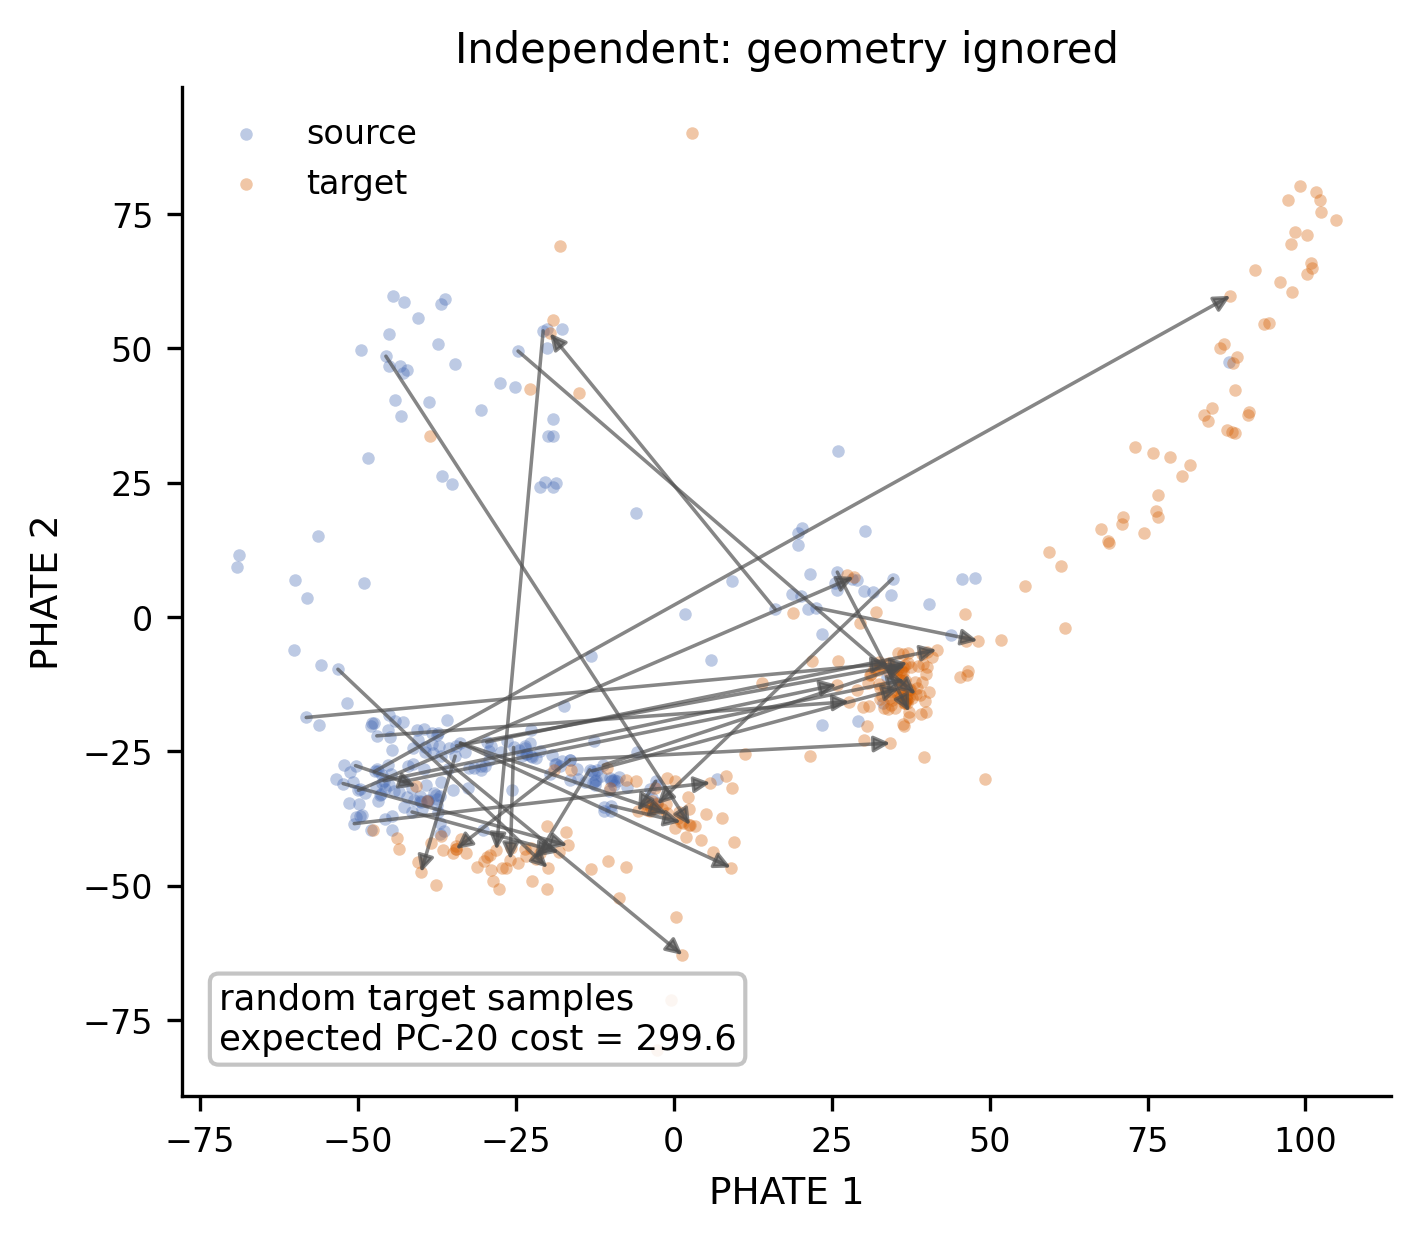

['figures/ch02/fig02_02a_static_ot_independent_endpoint_coupling.png',
 'figures/ch02/fig02_02a_static_ot_independent_endpoint_coupling.svg']

In [11]:
independent_expected_cost = float(coupling_table.loc[coupling_table["method"] == "independent", "expected_cost_raw"].iloc[0])

fig, ax = plt.subplots(figsize=(4.8, 4.2))
draw_endpoint_cloud(ax, X0_plot, X1_plot)
draw_arrows(ax, X0_plot, X1_plot, i0_ind, i1_ind, color="#4D4D4D", alpha=0.68, linewidth=0.85, mutation_scale=8.0)
ax.set_title("Independent: geometry ignored")
ax.set_xlabel("PHATE 1")
ax.set_ylabel("PHATE 2")
ax.legend(frameon=False, loc="best")
ax.text(
    0.03, 0.04,
    f"random target samples\nexpected PC-20 cost = {independent_expected_cost:.1f}",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=8.5,
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="#BBBBBB", alpha=0.86),
)
fig.tight_layout()
fig02_02a_paths = save_and_show(fig, "fig02_02a_static_ot_independent_endpoint_coupling")
fig02_02a_paths


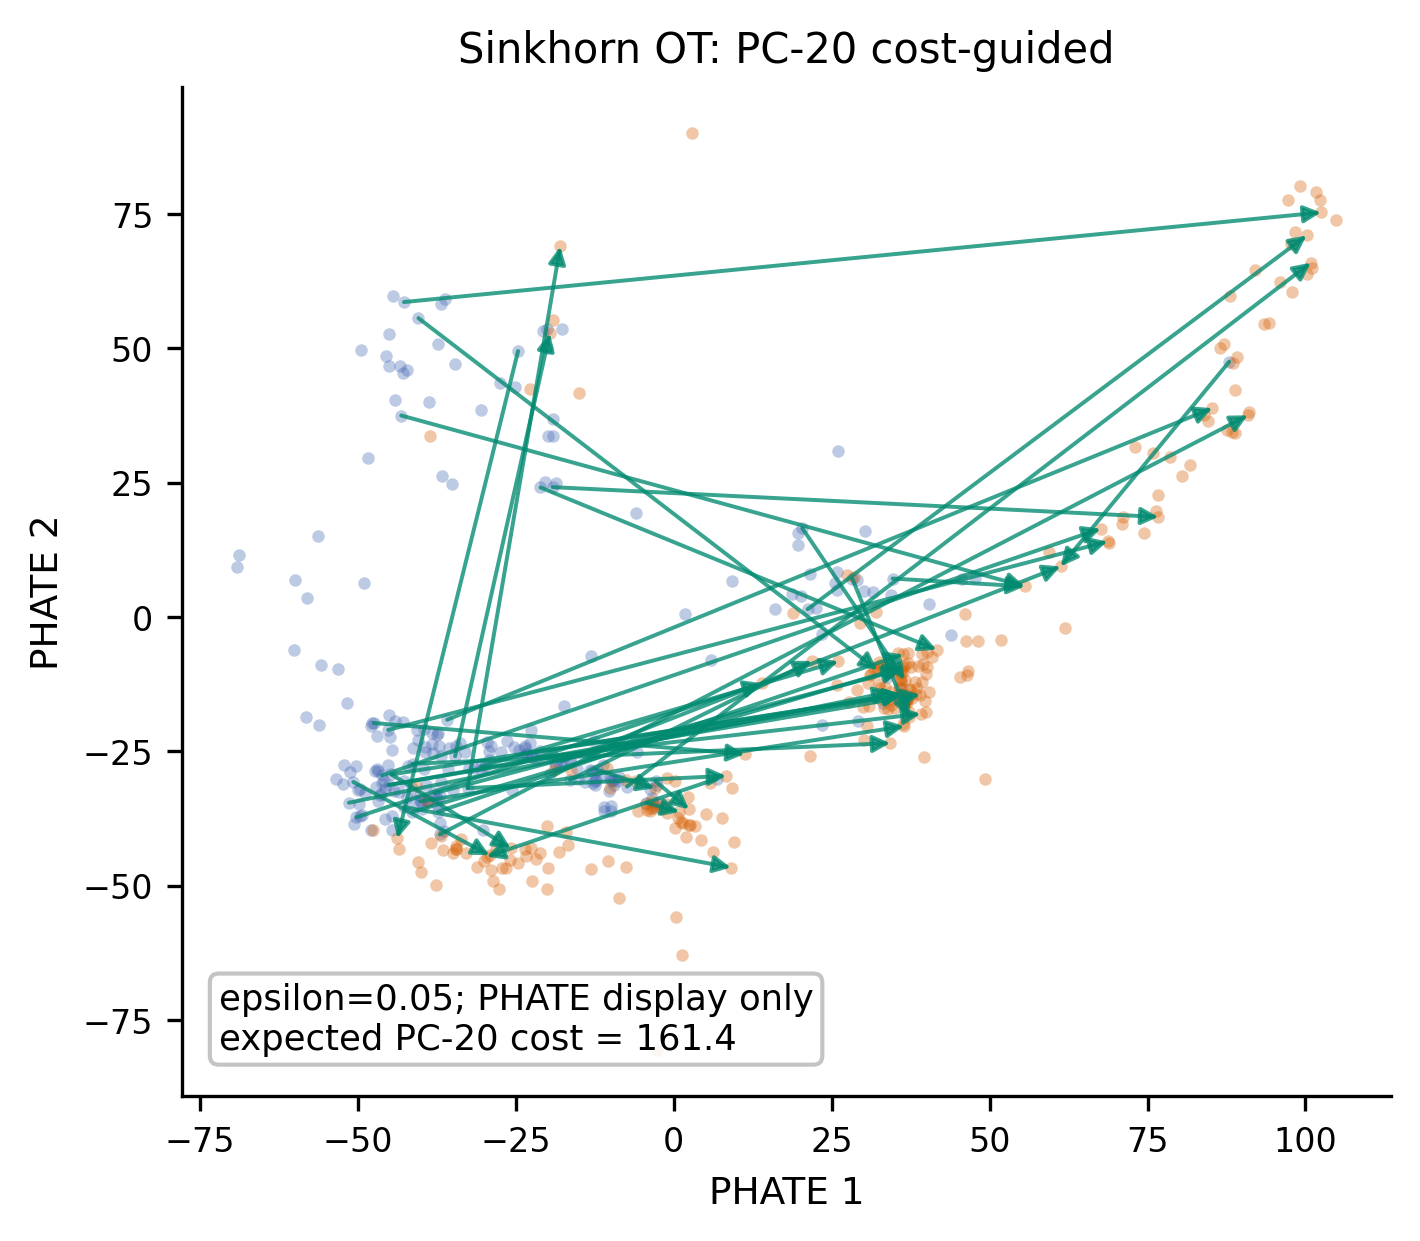

['figures/ch02/fig02_02b_static_ot_sinkhorn_endpoint_coupling.png',
 'figures/ch02/fig02_02b_static_ot_sinkhorn_endpoint_coupling.svg']

In [12]:
main_row_for_panel = coupling_table[(coupling_table["method"] == "sinkhorn_ot") & np.isclose(coupling_table["epsilon"], static_ot_main_epsilon)].iloc[0]
main_expected_cost = float(main_row_for_panel["expected_cost_raw"])

fig, ax = plt.subplots(figsize=(4.8, 4.2))
draw_endpoint_cloud(ax, X0_plot, X1_plot)
draw_arrows(ax, X0_plot, X1_plot, i0_ot, i1_ot, color="#008A70", alpha=0.78, linewidth=0.95, mutation_scale=8.5)
ax.set_title("Sinkhorn OT: PC-20 cost-guided")
ax.set_xlabel("PHATE 1")
ax.set_ylabel("PHATE 2")
ax.text(
    0.03, 0.04,
    f"epsilon={static_ot_main_epsilon}; PHATE display only\nexpected PC-20 cost = {main_expected_cost:.1f}",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=8.5,
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="#BBBBBB", alpha=0.86),
)
fig.tight_layout()
fig02_02b_paths = save_and_show(fig, "fig02_02b_static_ot_sinkhorn_endpoint_coupling")
fig02_02b_paths


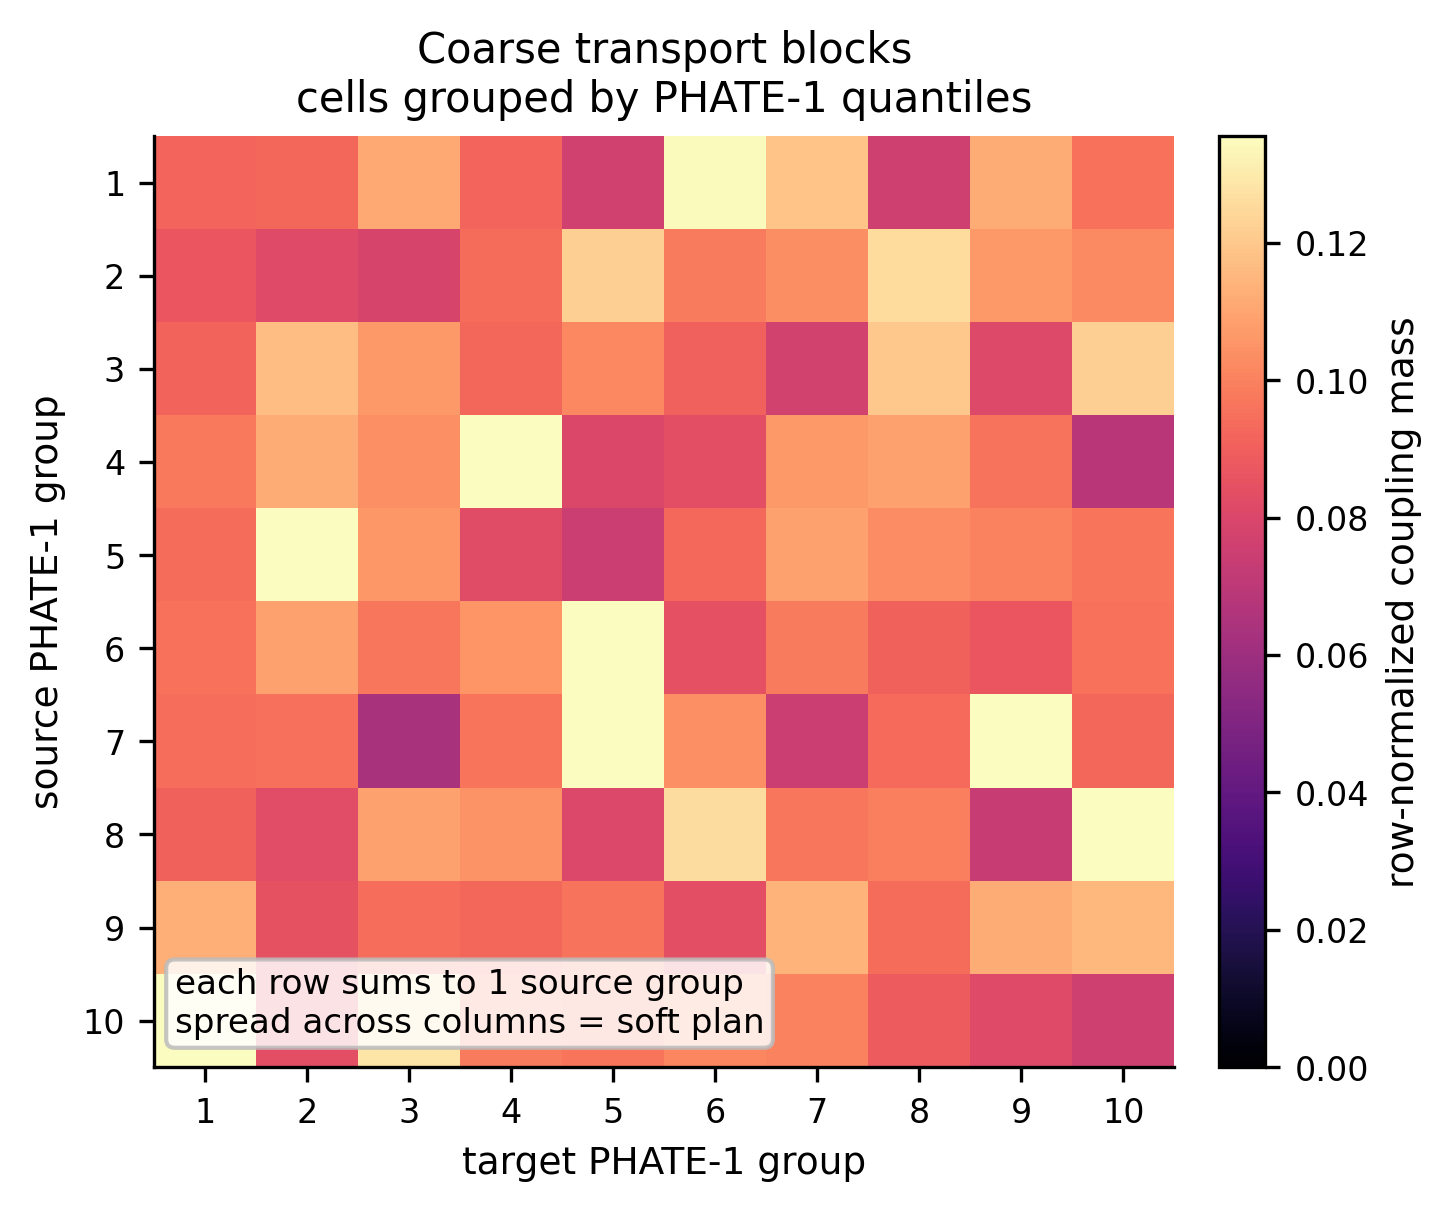

['figures/ch02/fig02_02c_static_ot_transport_plan_heatmap.png',
 'figures/ch02/fig02_02c_static_ot_transport_plan_heatmap.svg']

In [13]:
n_transport_bins = 10
source_bins = np.clip(
    np.searchsorted(np.quantile(X0_plot[:, 0], np.linspace(0, 1, n_transport_bins + 1))[1:-1], X0_plot[:, 0], side="right"),
    0,
    n_transport_bins - 1,
)
target_bins = np.clip(
    np.searchsorted(np.quantile(X1_plot[:, 0], np.linspace(0, 1, n_transport_bins + 1))[1:-1], X1_plot[:, 0], side="right"),
    0,
    n_transport_bins - 1,
)
source_membership = np.eye(n_transport_bins)[source_bins]
target_membership = np.eye(n_transport_bins)[target_bins]
coarse_pi = source_membership.T @ pi_main @ target_membership
row_sums = coarse_pi.sum(axis=1, keepdims=True)
row_normalized_coarse_pi = np.divide(coarse_pi, row_sums, out=np.zeros_like(coarse_pi), where=row_sums > 0)
color_max = max(0.12, float(np.quantile(row_normalized_coarse_pi, 0.95)))

fig, ax = plt.subplots(figsize=(4.9, 4.1))
im = ax.imshow(row_normalized_coarse_pi, aspect="auto", cmap="magma", vmin=0.0, vmax=color_max)
ticks = np.arange(n_transport_bins)
ax.set_xticks(ticks, ticks + 1)
ax.set_yticks(ticks, ticks + 1)
ax.set_title("Coarse transport blocks\ncells grouped by PHATE-1 quantiles")
ax.set_xlabel("target PHATE-1 group")
ax.set_ylabel("source PHATE-1 group")
ax.text(
    0.02, 0.03,
    "each row sums to 1 source group\nspread across columns = soft plan",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=8.2,
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="#BBBBBB", alpha=0.84),
)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="row-normalized coupling mass")
fig.tight_layout()
fig02_02c_paths = save_and_show(fig, "fig02_02c_static_ot_transport_plan_heatmap")
fig02_02c_paths


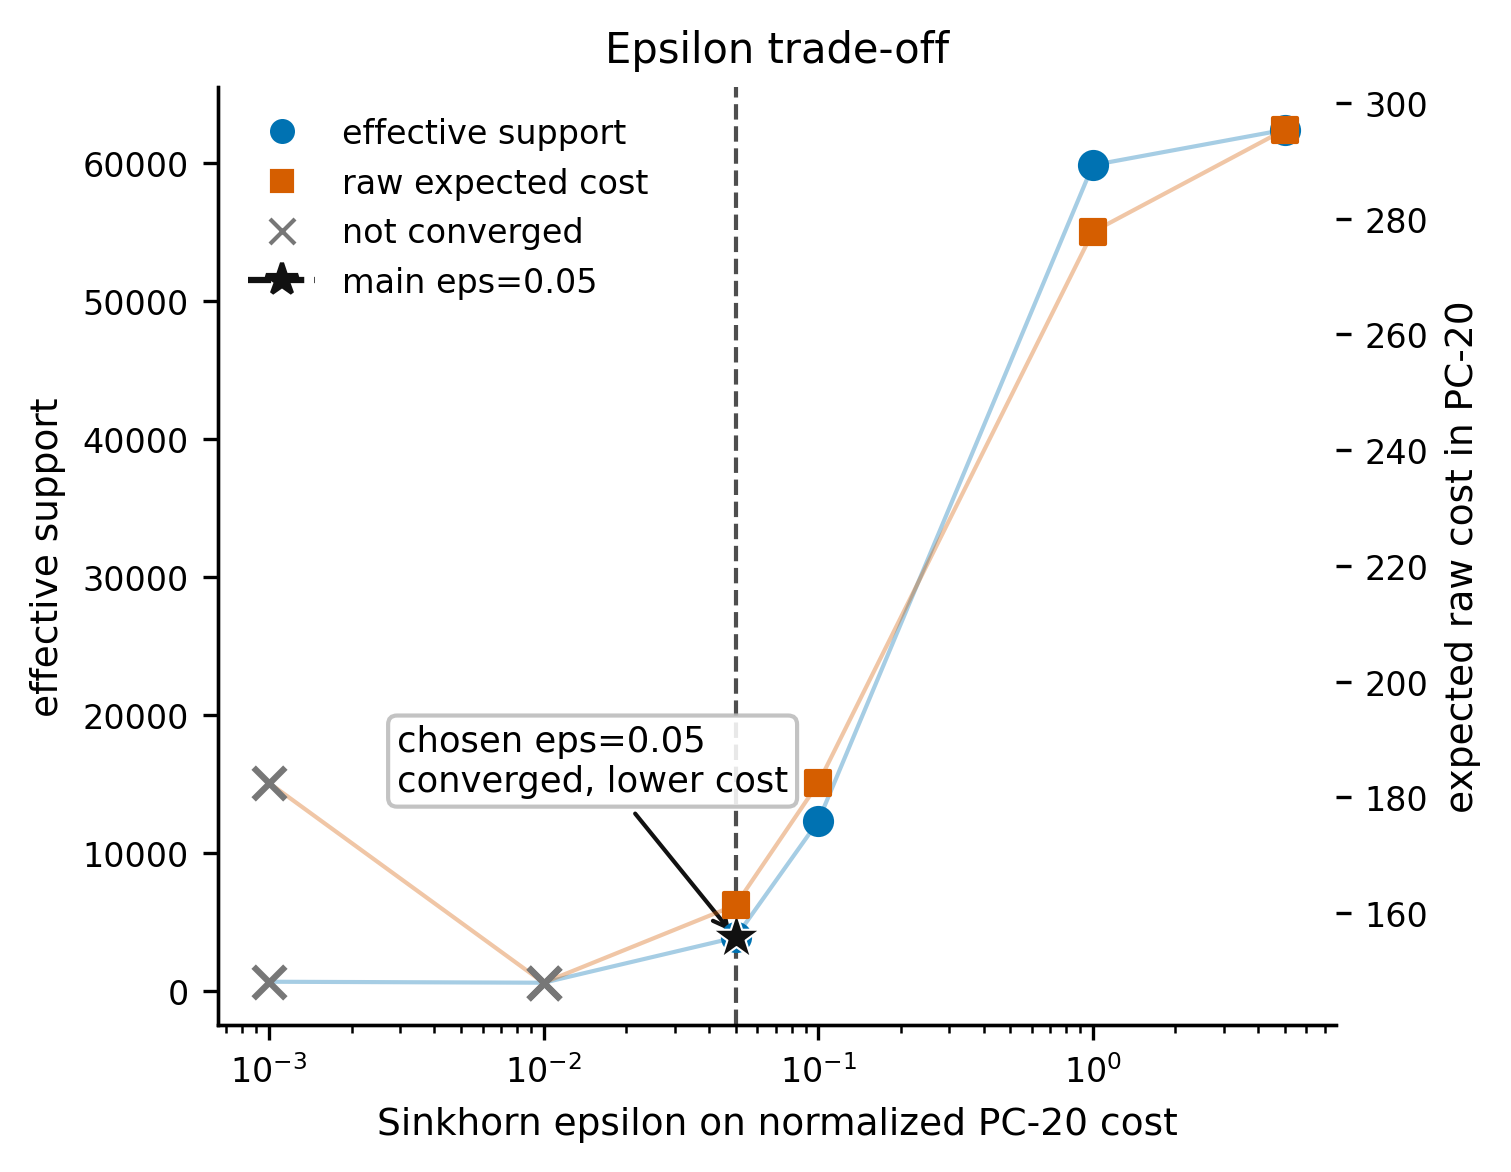

['figures/ch02/fig02_02a_static_ot_independent_endpoint_coupling.png',
 'figures/ch02/fig02_02a_static_ot_independent_endpoint_coupling.svg',
 'figures/ch02/fig02_02b_static_ot_sinkhorn_endpoint_coupling.png',
 'figures/ch02/fig02_02b_static_ot_sinkhorn_endpoint_coupling.svg',
 'figures/ch02/fig02_02c_static_ot_transport_plan_heatmap.png',
 'figures/ch02/fig02_02c_static_ot_transport_plan_heatmap.svg',
 'figures/ch02/fig02_02d_static_ot_epsilon_sensitivity.png',
 'figures/ch02/fig02_02d_static_ot_epsilon_sensitivity.svg']

In [14]:
eps_df = coupling_table[coupling_table["method"] == "sinkhorn_ot"].copy()
converged = eps_df["sinkhorn_converged"].astype(bool).to_numpy()
eps_values = eps_df["epsilon"].to_numpy(dtype=float)
support_values = eps_df["effective_support"].to_numpy(dtype=float)
cost_values = eps_df["expected_cost_raw"].to_numpy(dtype=float)
main_row = eps_df[np.isclose(eps_df["epsilon"], static_ot_main_epsilon)].iloc[0]
independent_expected_cost = float(coupling_table.loc[coupling_table["method"] == "independent", "expected_cost_raw"].iloc[0])
main_expected_cost = float(main_row["expected_cost_raw"])

fig, ax = plt.subplots(figsize=(5.1, 4.0))
ax.plot(eps_values, support_values, color="#0072B2", alpha=0.35, linewidth=1.0)
ax.scatter(eps_values[converged], support_values[converged], marker="o", s=42, color="#0072B2", zorder=4)
ax.scatter(eps_values[~converged], support_values[~converged], marker="x", s=58, color="#777777", linewidths=1.5, zorder=5)
ax.set_xscale("log")
ax.set_xlabel("Sinkhorn epsilon on normalized PC-20 cost")
ax.set_ylabel("effective support")
ax.axvline(static_ot_main_epsilon, color="#222222", linestyle="--", linewidth=1.0, alpha=0.8)
ax.scatter([static_ot_main_epsilon], [float(main_row["effective_support"])], marker="*", s=145, color="#111111", edgecolors="white", linewidths=0.5, zorder=6)

ax2 = ax.twinx()
ax2.plot(eps_values, cost_values, color="#D55E00", alpha=0.35, linewidth=1.0)
ax2.scatter(eps_values[converged], cost_values[converged], marker="s", s=34, color="#D55E00", zorder=4)
ax2.scatter(eps_values[~converged], cost_values[~converged], marker="x", s=58, color="#777777", linewidths=1.5, zorder=5)
ax2.set_ylabel("expected raw cost in PC-20")
ax.set_title("Epsilon trade-off")
ax.legend(
    handles=[
        Line2D([0], [0], marker="o", color="#0072B2", linestyle="None", markersize=5, label="effective support"),
        Line2D([0], [0], marker="s", color="#D55E00", linestyle="None", markersize=5, label="raw expected cost"),
        Line2D([0], [0], marker="x", color="#777777", linestyle="None", markersize=6, label="not converged"),
        Line2D([0], [0], marker="*", color="#111111", linestyle="--", markersize=8, label="main eps=0.05"),
    ],
    frameon=False,
    loc="best",
)
ax.annotate(
    "chosen eps=0.05\nconverged, lower cost",
    xy=(static_ot_main_epsilon, float(main_row["effective_support"])),
    xytext=(0.16, 0.25),
    textcoords="axes fraction",
    arrowprops=dict(arrowstyle="->", color="#111111", lw=1.0),
    fontsize=8.5,
    ha="left",
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="#BBBBBB", alpha=0.88),
)
fig.tight_layout()
fig02_02d_paths = save_and_show(fig, "fig02_02d_static_ot_epsilon_sensitivity")
fig02_02d_paths
fig02_02_paths = fig02_02a_paths + fig02_02b_paths + fig02_02c_paths + fig02_02d_paths
fig02_02_paths


Figure 2.2 and Table 2.1 summarize the static endpoint-coupling result. Sinkhorn OT at ε=0.05 reduces expected PC-20 transport cost from 299.6 to 161.4, while concentrating mass relative to the independent coupling. Smaller ε may reduce cost further but did not converge in this run. The 299.6 to 161.4 change is approximately 46% lower than the independent baseline. PHATE is visualization only, and the OT plan is a model-implied endpoint coupling, not observed lineage.


## 4. Optional OT Cost Sensitivity Across PC Dimensions

Question: does the endpoint plan materially change if the same EB snapshots are compared in PC-5, PC-10, PC-20, or PC-50? We recompute Sinkhorn OT at ε=0.05 and compare each plan to the PC-20 plan by L1 distance.


In [15]:
eb50 = load_eb_timecourse_for_ch03(
    path=eb_path,
    cost_embedding="pcs",
    plot_embedding="phate",
    n_cost_dims=50,
    max_cells_per_time=max_cells_per_time,
    seed=seed,
)
labels50 = eb50["time"].astype(str)
rng_sensitivity = np.random.default_rng(seed + 90)
idx0_sens = subsample_indices(np.flatnonzero(labels50 == source_time), n_source_ot, rng_sensitivity)
idx1_sens = subsample_indices(np.flatnonzero(labels50 == target_time), n_target_ot, rng_sensitivity)

pc_dim_values = [5, 10, 20, 50]
sensitivity_plans = {}
sensitivity_rows = []
for pc_dims in pc_dim_values:
    X0_dim = np.asarray(eb50["X_cost"][idx0_sens, :pc_dims], dtype=float)
    X1_dim = np.asarray(eb50["X_cost"][idx1_sens, :pc_dims], dtype=float)
    C_dim_raw = pairwise_squared_distances(X0_dim, X1_dim)
    scale_dim = median_positive_scale(C_dim_raw)
    C_dim_norm = C_dim_raw / max(scale_dim, 1e-12)
    pi_dim, info_dim = compute_ot_coupling_from_cost(C_dim_norm, epsilon=static_ot_main_epsilon, return_info=True)
    sensitivity_plans[int(pc_dims)] = pi_dim
    diag_dim = coupling_diagnostics(pi_dim, C_dim_raw)
    sensitivity_rows.append(
        {
            "pc_dims": int(pc_dims),
            "epsilon": static_ot_main_epsilon,
            "expected_cost_raw": diag_dim["expected_cost"],
            "entropy": diag_dim["entropy"],
            "effective_support": diag_dim["effective_support"],
            "row_l1_error": diag_dim["row_l1_error"],
            "col_l1_error": diag_dim["col_l1_error"],
            "sinkhorn_converged": bool(info_dim.get("sinkhorn_converged", False)),
            "sinkhorn_backend": str(info_dim.get("backend", "")),
            "cost_scale": float(scale_dim),
        }
    )

pc20_plan_for_sensitivity = sensitivity_plans[20]
for row in sensitivity_rows:
    row["l1_to_pc20_plan"] = coupling_l1_distance(sensitivity_plans[int(row["pc_dims"])], pc20_plan_for_sensitivity)

ot_cost_sensitivity_table = pd.DataFrame(sensitivity_rows)
table02_optional_path = save_ch02_table(ot_cost_sensitivity_table, out_dir, "table02_optional_ot_cost_sensitivity.csv", paper_root)
table_preview(ot_cost_sensitivity_table, columns=["pc_dims", "epsilon", "expected_cost_raw", "effective_support", "l1_to_pc20_plan"], n=8)


,pc_dims,epsilon,expected_cost_raw,effective_support,l1_to_pc20_plan
0,5,0.05,67.782844,4808.313063,1.302791
1,10,0.05,108.136977,3956.627337,0.813855
2,20,0.05,157.675060,4017.558193,0.000000
3,50,0.05,227.991956,4999.141525,0.572888


The sensitivity table changes only the feature dimension used for the static endpoint cost. It does not establish a unique biological pairing, and it does not change the chapter's main PC-20 convention.


## 5. Same Endpoints, Different Paths

Question: does an endpoint coupling determine a trajectory? This section supports Figure 2.3. We use a toy 2D branching snapshot system, sample the same endpoint pairs from an OT endpoint coupling, and draw three bridge families: straight, curved deterministic, and Brownian stochastic.

The core lesson is that the same endpoint pairs can support different intermediate paths. Read the four panels together: the endpoint relation stays fixed, but the path semantics change completely.


In [16]:
toy = make_y_branching_snapshots(
    n_cells=400,
    timepoints=(0.0, 1.0),
    rare_fate_fraction=0.5,
    noise=0.075,
    seed=seed,
)
toy_X = np.asarray(toy.X, dtype=float)
toy_times = np.asarray(toy.time, dtype=float)
toy_X0 = toy_X[np.isclose(toy_times, 0.0)]
toy_X1 = toy_X[np.isclose(toy_times, 1.0)]

toy_C_raw = pairwise_squared_distances(toy_X0, toy_X1)
toy_C_norm = toy_C_raw / max(median_positive_scale(toy_C_raw), 1e-12)
toy_pi = compute_ot_coupling_from_cost(toy_C_norm, epsilon=static_ot_main_epsilon)
toy_i0, toy_i1 = sample_pair_indices_from_coupling(toy_pi, batch_size=80, seed=seed + 20)
toy_x0 = toy_X0[toy_i0]
toy_x1 = toy_X1[toy_i1]
toy_sampled_endpoint_pairs = pd.DataFrame({"source_local_index": toy_i0, "target_local_index": toy_i1})
toy_sampled_endpoint_pairs.head()


,source_local_index,target_local_index
0,121,173
1,149,106
2,156,26
3,57,113
4,138,129


In [17]:
tau_grid = np.linspace(0.0, 1.0, 51)
straight_bridge = np.stack([linear_path(toy_x0, toy_x1, tau)[0] for tau in tau_grid], axis=0)
curved_bridge = np.stack([curved_path(toy_x0, toy_x1, tau, curvature=0.20, direction="normal") for tau in tau_grid], axis=0)
brownian_bridge = brownian_bridge_trajectories(toy_x0, toy_x1, tau_grid, sigma=0.23, seed=seed + 21)
straight_midpoint = 0.5 * (toy_x0 + toy_x1)

{
    "straight_bridge_shape": straight_bridge.shape,
    "curved_bridge_shape": curved_bridge.shape,
    "brownian_bridge_shape": brownian_bridge.shape,
}


{'straight_bridge_shape': (51, 80, 2),
 'curved_bridge_shape': (51, 80, 2),
 'brownian_bridge_shape': (51, 80, 2)}

In [18]:
path_rows = []
for path_family, traj, notes in [
    ("straight bridge", straight_bridge, "Native 2D straight interpolation for the sampled endpoint pairs."),
    ("curved deterministic bridge", curved_bridge, "Native 2D deterministic bridge with fixed endpoint coupling."),
    ("Brownian stochastic bridge", brownian_bridge, "Discrete sampled-path proxy; not a strong action conclusion."),
]:
    stats = path_stats(traj, tau_grid, straight_midpoint)
    midpoint = traj[int(np.argmin(np.abs(tau_grid - 0.5)))]
    if path_family == "Brownian stochastic bridge":
        midpoint_spread = float(np.linalg.norm(midpoint - midpoint.mean(axis=0, keepdims=True), axis=1).mean())
    elif path_family == "straight bridge":
        midpoint_spread = 0.0
    else:
        midpoint_spread = float(np.std(np.linalg.norm(midpoint - straight_midpoint, axis=1)))
    path_rows.append(
        {
            "path_family": path_family,
            **stats,
            "midpoint_spread": midpoint_spread,
            "n_pairs": int(len(toy_x0)),
            "n_steps": int(len(tau_grid)),
            "notes": notes,
        }
    )

path_diagnostics = pd.DataFrame(path_rows)
table02_02_path = save_ch02_table(path_diagnostics, out_dir, "table02_02_path_diagnostics.csv", paper_root)
table_preview(path_diagnostics, columns=["path_family", "mean_path_length", "energy_proxy", "midpoint_deviation", "midpoint_spread"], n=8)


,path_family,mean_path_length,energy_proxy,midpoint_deviation,midpoint_spread
0,straight bridge,2.484923,6.185510,0.000000,0.000000
1,curved deterministic bridge,2.714418,7.406079,0.496985,0.020657
2,Brownian stochastic bridge,3.076432,11.316080,0.151573,0.470345


Each path construction is rendered as its own small figure so the endpoint-pair ambiguity is visible step by step.


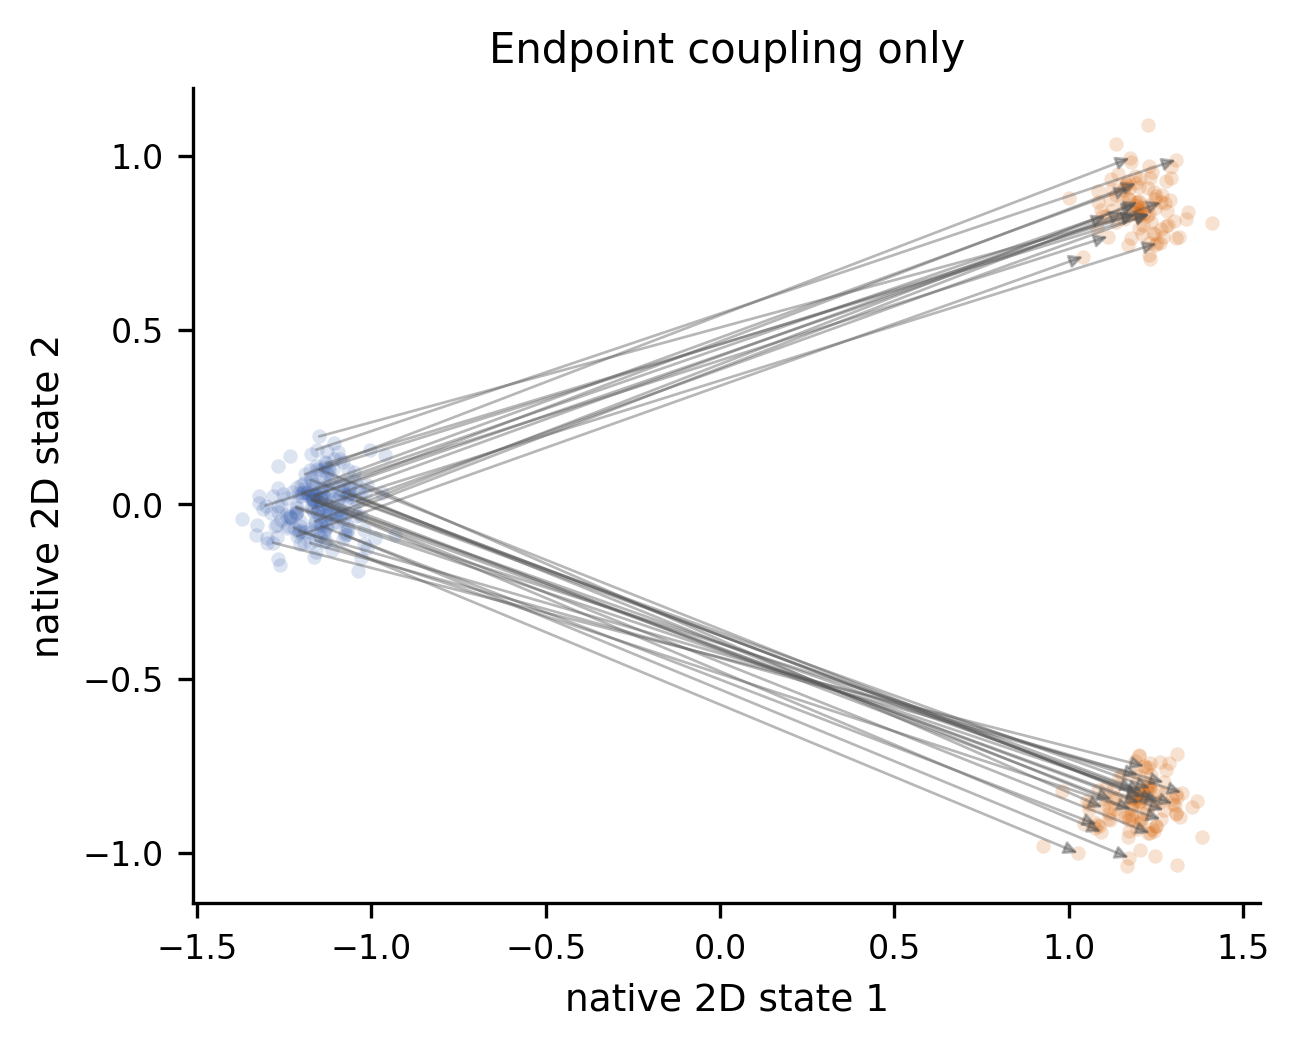

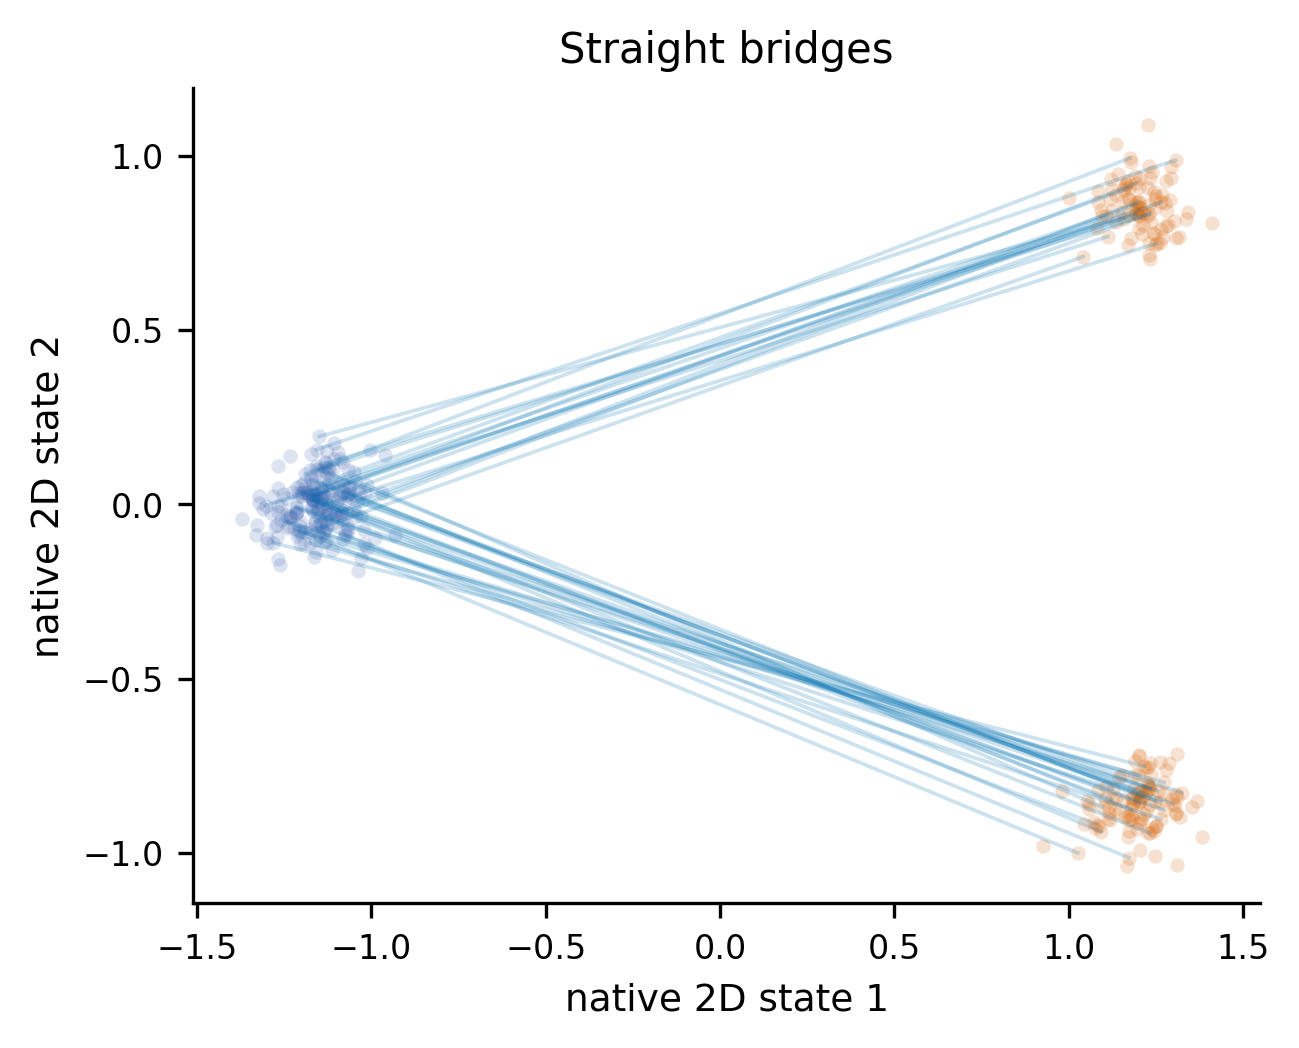

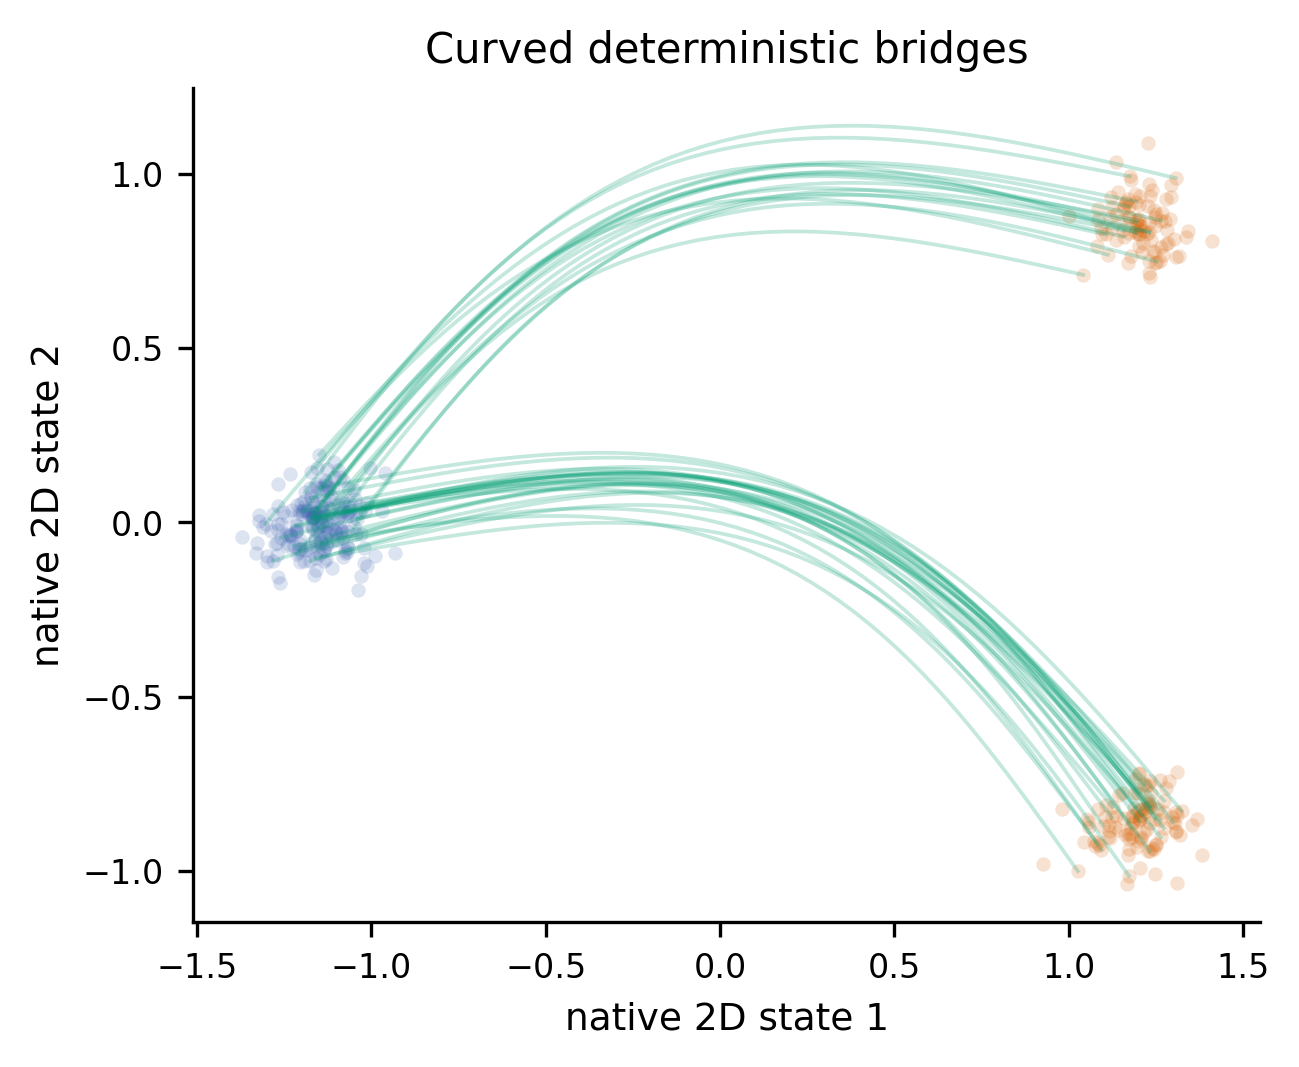

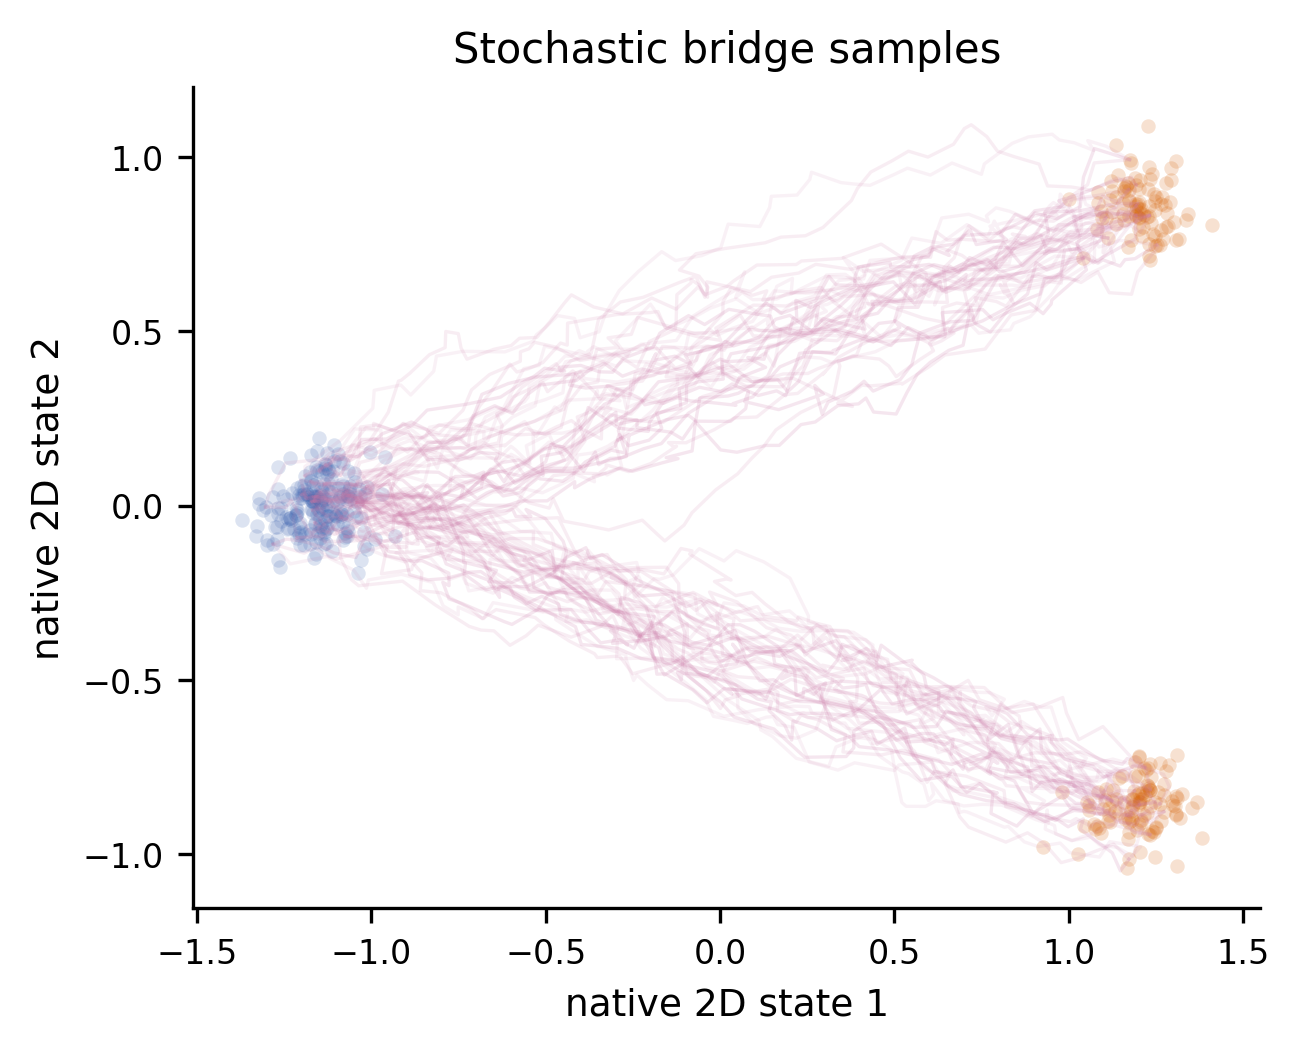

['figures/ch02/fig02_03a_endpoint_coupling_only.png',
 'figures/ch02/fig02_03a_endpoint_coupling_only.svg',
 'figures/ch02/fig02_03b_straight_bridges.png',
 'figures/ch02/fig02_03b_straight_bridges.svg',
 'figures/ch02/fig02_03c_curved_bridges.png',
 'figures/ch02/fig02_03c_curved_bridges.svg',
 'figures/ch02/fig02_03d_stochastic_bridge_samples.png',
 'figures/ch02/fig02_03d_stochastic_bridge_samples.svg']

In [19]:
background_kw = dict(s=12, alpha=0.18, linewidths=0)
path_count = 42


def draw_endpoint_panel(ax):
    draw_arrows(ax, toy_X0, toy_X1, toy_i0[:38], toy_i1[:38], color="#555555", alpha=0.42, linewidth=0.65, mutation_scale=6.5)


def draw_straight_panel(ax):
    for pair_idx in range(path_count):
        ax.plot(straight_bridge[:, pair_idx, 0], straight_bridge[:, pair_idx, 1], color="#0072B2", alpha=0.20, linewidth=0.9)


def draw_curved_panel(ax):
    for pair_idx in range(path_count):
        ax.plot(curved_bridge[:, pair_idx, 0], curved_bridge[:, pair_idx, 1], color="#009E73", alpha=0.23, linewidth=0.9)


def draw_stochastic_panel(ax):
    for repeat, alpha in enumerate([0.18, 0.13, 0.10]):
        stoch_plot = brownian_bridge_trajectories(toy_x0[:24], toy_x1[:24], tau_grid, sigma=0.23, seed=seed + 30 + repeat)
        for pair_idx in range(stoch_plot.shape[1]):
            ax.plot(stoch_plot[:, pair_idx, 0], stoch_plot[:, pair_idx, 1], color="#CC79A7", alpha=alpha, linewidth=0.8)


bridge_panels = [
    ("fig02_03a_endpoint_coupling_only", "Endpoint coupling only", draw_endpoint_panel),
    ("fig02_03b_straight_bridges", "Straight bridges", draw_straight_panel),
    ("fig02_03c_curved_bridges", "Curved deterministic bridges", draw_curved_panel),
    ("fig02_03d_stochastic_bridge_samples", "Stochastic bridge samples", draw_stochastic_panel),
]

fig02_03_paths = []
for stem, title, draw_fn in bridge_panels:
    fig, ax = plt.subplots(figsize=(4.4, 3.8))
    ax.scatter(toy_X0[:, 0], toy_X0[:, 1], c="#4267B2", **background_kw)
    ax.scatter(toy_X1[:, 0], toy_X1[:, 1], c="#D55E00", **background_kw)
    draw_fn(ax)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("native 2D state 1")
    ax.set_ylabel("native 2D state 2")
    ax.set_title(title)
    fig.tight_layout()
    fig02_03_paths += save_and_show(fig, stem)

fig02_03_paths


These bridges share endpoint pairs but differ between endpoints. The example shows non-identifiability of paths from endpoint couplings; it is not a lineage reconstruction and it is not evidence that any one toy bridge is biologically observed.


## 6. Dynamic OT Low-Action Intuition On EB

Question: why does dynamic OT motivate low-action paths through the data geometry? This section supports Figure 2.4 and Table 2.3. We compare a fixed set of EB source-target endpoint pairs under two constructed path families: a straight PC-20 bridge and a perpendicular PC-20 detour.

The endpoints and PC-20 OT coupling are held fixed. Only the intermediate path is changed. PHATE is used only to display selected endpoints, while all action proxies are computed in PC-20. The key number is the detour/straight action ratio; it quantifies why low-action paths are favored without claiming that we solved Benamou-Brenier dynamic OT or observed lineage.


In [20]:
try:
    import phate
except ImportError as exc:
    raise ImportError("phate is required for Chapter 2 EB endpoint visualization.") from exc

phate_model = phate.PHATE(
    n_components=2,
    knn=5,
    decay=40,
    n_landmark=min(2000, int(X_pc20.shape[0])),
    random_state=int(seed),
    n_jobs=1,
    verbose=0,
)
phate_model.fit(X_pc20)

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="Pre-fit PHATE should not be used.*")
    X_phate_fit = np.asarray(phate_model.transform(X_pc20), dtype=float)

X_phate_fit.shape


(4500, 2)

In [21]:
rng_dynamic = np.random.default_rng(seed + 40)
dynamic_colors = {
    "background": "#9ca3af",
    "connection": "#6b7280",
    "source": "#1f77b4",
    "target": "#d95f02",
    "straight": "#1f77b4",
    "detour": "#d95f02",
    "mean": "#111111",
}
print("Dynamic OT panel colors configured for plotting only.")


Dynamic OT panel colors configured for plotting only.


In [22]:
pair_i0, pair_i1 = sample_pair_indices_from_coupling(pi_main, batch_size=20, seed=seed + 60)
dynamic_pair_x0 = X0_cost[pair_i0]
dynamic_pair_x1 = X1_cost[pair_i1]
dynamic_source_phate = X_phate_fit[idx0[pair_i0]]
dynamic_target_phate = X_phate_fit[idx1[pair_i1]]
dynamic_tau_grid = np.linspace(0.0, 1.0, 41)

economical_pc20 = (
    (1.0 - dynamic_tau_grid[:, None, None]) * dynamic_pair_x0[None, :, :]
    + dynamic_tau_grid[:, None, None] * dynamic_pair_x1[None, :, :]
)

direction = dynamic_pair_x1 - dynamic_pair_x0
random_vec = rng_dynamic.normal(size=direction.shape)
projection = (
    np.sum(random_vec * direction, axis=1, keepdims=True)
    / np.clip(np.sum(direction**2, axis=1, keepdims=True), 1e-12, None)
) * direction
perpendicular = random_vec - projection
perpendicular /= np.clip(np.linalg.norm(perpendicular, axis=1, keepdims=True), 1e-12, None)
amplitude = 0.75 * np.linalg.norm(direction, axis=1, keepdims=True)
detour_pc20 = economical_pc20 + np.sin(np.pi * dynamic_tau_grid)[:, None, None] * amplitude[None, :, :] * perpendicular[None, :, :]

sampled_dynamic_endpoint_pairs = pd.DataFrame(
    {
        "source_local_index": pair_i0,
        "target_local_index": pair_i1,
        "source_global_index": idx0[pair_i0],
        "target_global_index": idx1[pair_i1],
        "coupling": "same_pc20_sinkhorn_ot_coupling",
    }
)
sampled_dynamic_endpoint_pairs.head()


,source_local_index,target_local_index,source_global_index,target_global_index,coupling
0,39,244,1033,2682,same_pc20_sinkhorn_ot_coupling
1,146,142,1410,2356,same_pc20_sinkhorn_ot_coupling
2,205,237,1589,2642,same_pc20_sinkhorn_ot_coupling
3,74,92,1172,2169,same_pc20_sinkhorn_ot_coupling
4,171,10,1489,1847,same_pc20_sinkhorn_ot_coupling


In [23]:
straight_action_per_pair = action_per_pair_pc(economical_pc20, dynamic_tau_grid)
detour_action_per_pair = action_per_pair_pc(detour_pc20, dynamic_tau_grid)
energy_economical, length_economical = energy_and_length_pc(economical_pc20, dynamic_tau_grid)
energy_detour, length_detour = energy_and_length_pc(detour_pc20, dynamic_tau_grid)

if not np.isclose(energy_economical, straight_action_per_pair.mean()):
    raise ValueError("Straight action mean does not match aggregate PC-20 energy proxy.")
if not np.isclose(energy_detour, detour_action_per_pair.mean()):
    raise ValueError("Detour action mean does not match aggregate PC-20 energy proxy.")

dynamic_ot_energy_ratio_detour_over_economical = energy_detour / max(energy_economical, 1e-12)
pair_action_table = pd.DataFrame(
    {
        "pair_index": np.arange(len(straight_action_per_pair), dtype=int),
        "straight_action_pc20": straight_action_per_pair,
        "detour_action_pc20": detour_action_per_pair,
        "detour_over_straight": detour_action_per_pair / np.clip(straight_action_per_pair, 1e-12, None),
    }
)

energy_table = pd.DataFrame(
    [
        {
            "path_family": "straight_pc20",
            "energy_proxy": energy_economical,
            "mean_path_length_pc20": length_economical,
            "n_pairs": int(len(dynamic_pair_x0)),
            "n_steps": int(len(dynamic_tau_grid)),
            "notes": "Straight PC-20 bridge for the same sampled OT endpoint pairs.",
        },
        {
            "path_family": "detour_perpendicular_pc20",
            "energy_proxy": energy_detour,
            "mean_path_length_pc20": length_detour,
            "n_pairs": int(len(dynamic_pair_x0)),
            "n_steps": int(len(dynamic_tau_grid)),
            "notes": "Fixed perpendicular perturbation in PC-20; endpoints and coupling unchanged.",
        },
    ]
)
table02_03_path = save_ch02_table(energy_table, out_dir, "table02_03_dynamic_ot_energy_proxy.csv", paper_root)
table_preview(energy_table, columns=["path_family", "energy_proxy", "mean_path_length_pc20", "n_pairs", "n_steps"], n=8)


,path_family,energy_proxy,mean_path_length_pc20,n_pairs,n_steps
0,straight_pc20,204.625449,13.462652,20,41
1,detour_perpendicular_pc20,772.338220,25.121004,20,41


In [24]:
dynamic_chord_progress = dynamic_tau_grid.copy()
dynamic_detour_displacement = np.sin(np.pi * dynamic_chord_progress)[:, None] * amplitude.ravel()[None, :]
amplitude_order = np.argsort(amplitude.ravel())
representative_dynamic_pairs = amplitude_order[np.linspace(
    0,
    len(amplitude_order) - 1,
    min(5, len(amplitude_order)),
    dtype=int,
)]

print(
    f"Dynamic OT panels use {len(dynamic_pair_x0)} fixed endpoint pairs; "
    f"{len(representative_dynamic_pairs)} representative detours are highlighted."
)
print(
    f"Mean PC-20 action: straight={straight_action_per_pair.mean():.2f}, "
    f"detour={detour_action_per_pair.mean():.2f}, "
    f"ratio={dynamic_ot_energy_ratio_detour_over_economical:.2f}."
)


Dynamic OT panels use 20 fixed endpoint pairs; 5 representative detours are highlighted.
Mean PC-20 action: straight=204.63, detour=772.34, ratio=3.77.


Dynamic OT low-action intuition is saved as three separate panel-level figures: fixed EB endpoint pairs, path-local construction with fixed endpoints, and a paired PC-20 action proxy. PHATE appears only in the endpoint display panel.


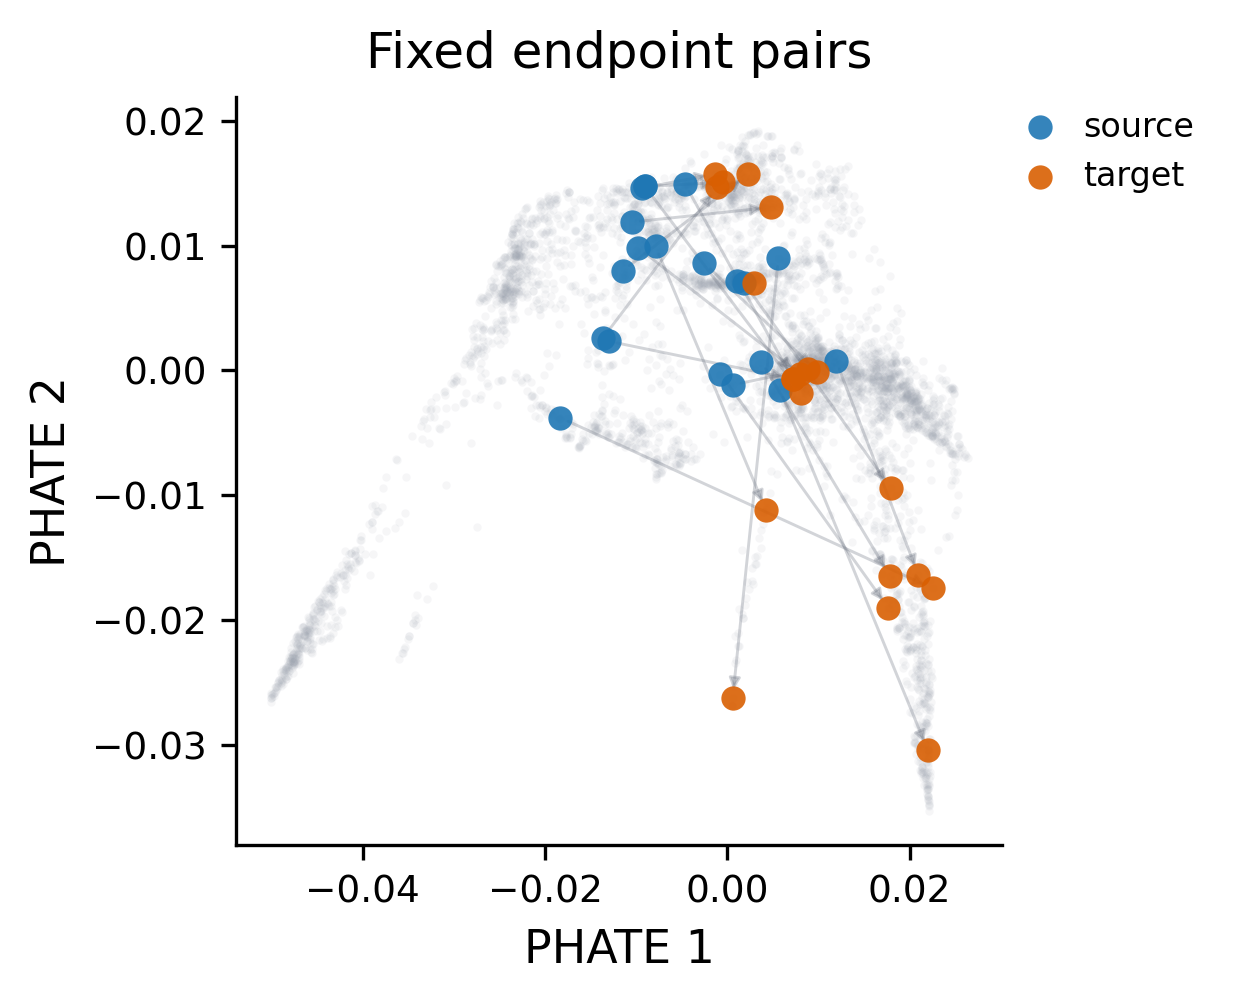

['figures/ch02/fig02_04a_fixed_endpoint_pairs.png',
 'figures/ch02/fig02_04a_fixed_endpoint_pairs.svg']

In [25]:
fig, ax = plt.subplots(figsize=(4.2, 3.4))
draw_fixed_endpoint_pairs_panel(
    ax,
    X_phate_fit,
    dynamic_source_phate,
    dynamic_target_phate,
    dynamic_colors,
)
fig.tight_layout()
fig02_04a_paths = save_and_show(fig, "fig02_04a_fixed_endpoint_pairs")
fig02_04a_paths


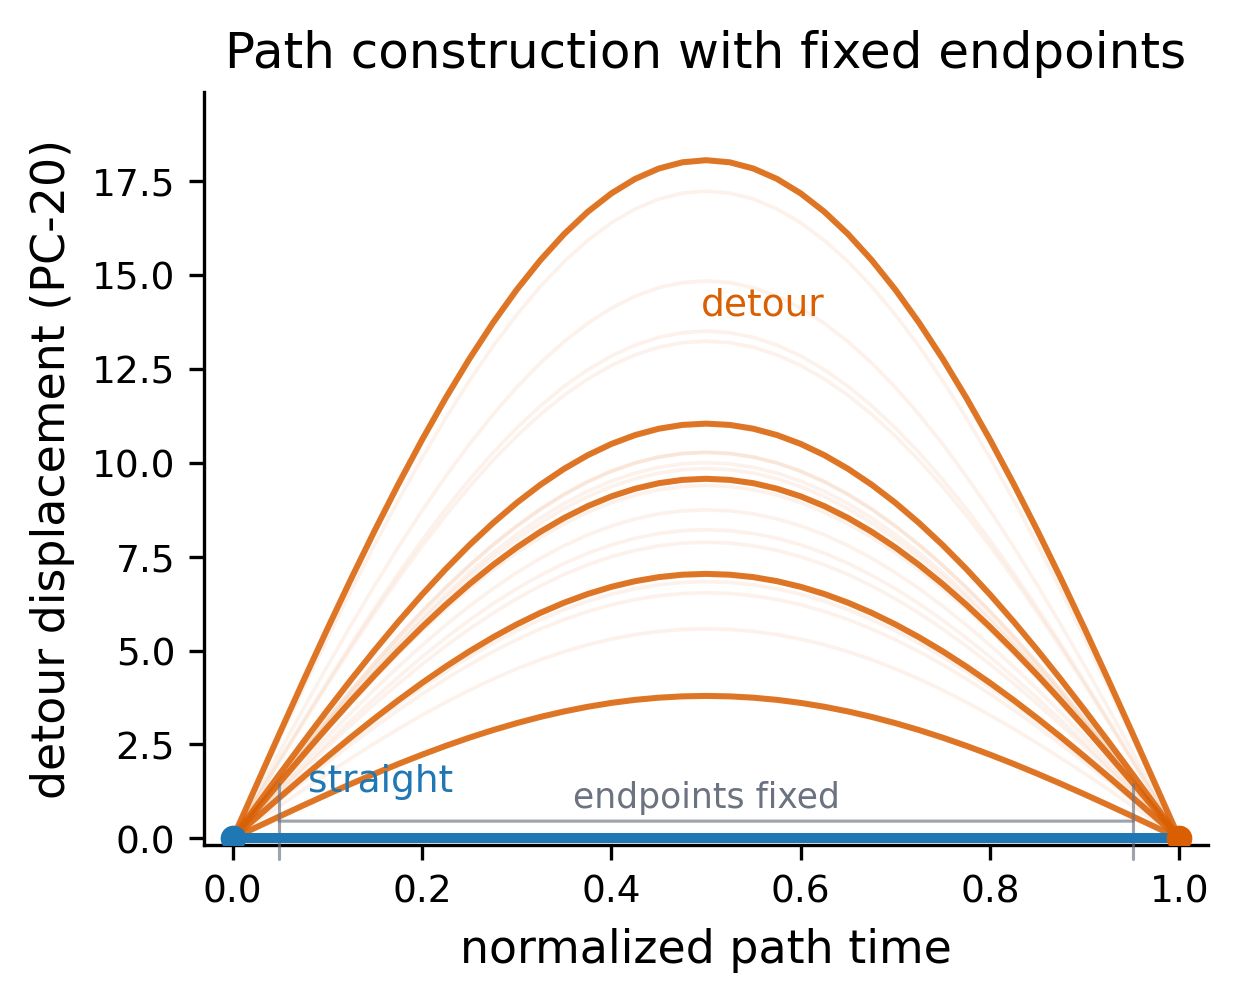

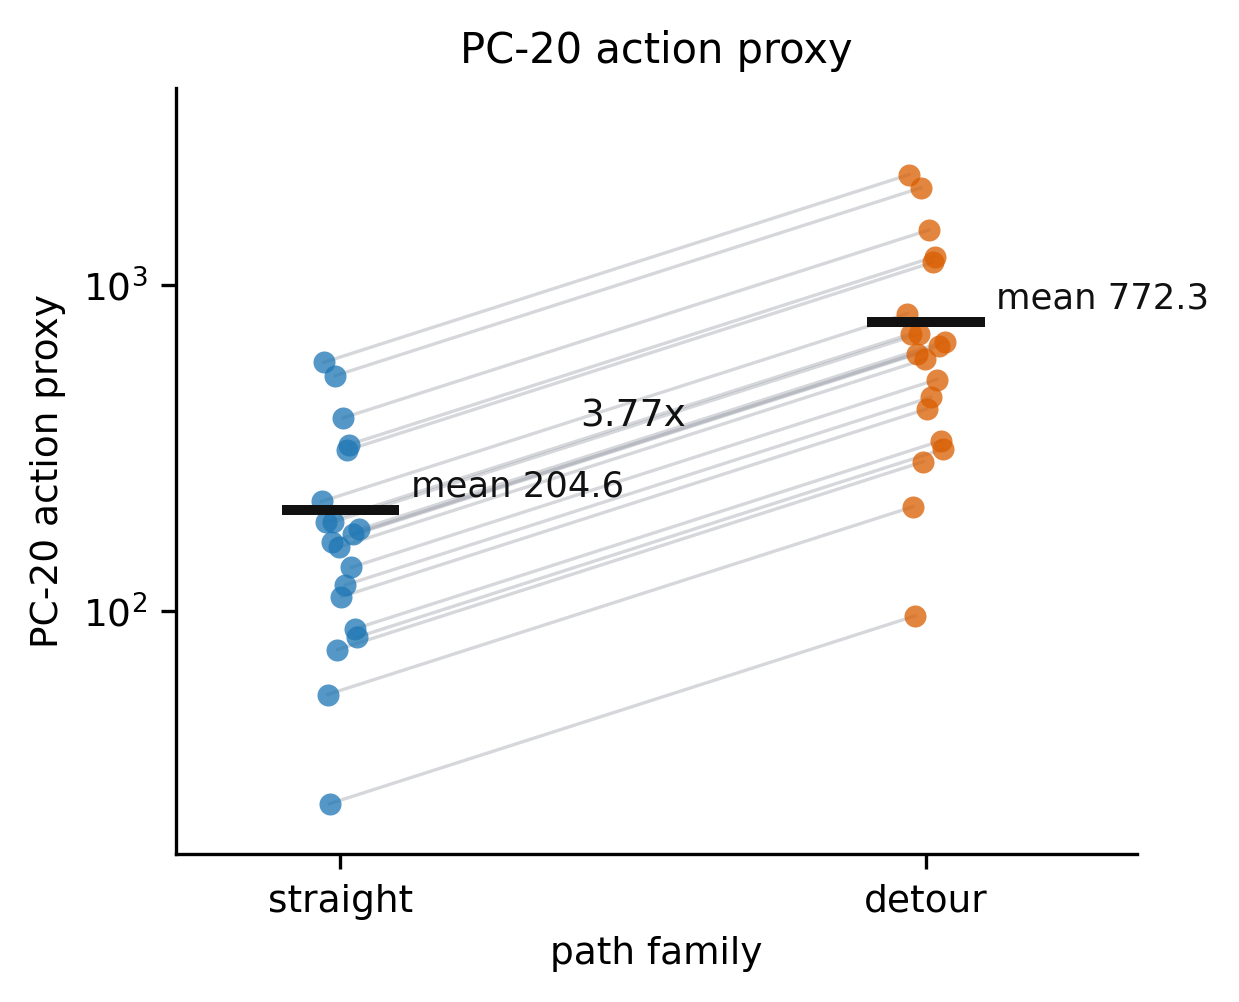

['figures/ch02/fig02_04a_fixed_endpoint_pairs.png',
 'figures/ch02/fig02_04a_fixed_endpoint_pairs.svg',
 'figures/ch02/fig02_04b_path_construction_fixed_endpoints.png',
 'figures/ch02/fig02_04b_path_construction_fixed_endpoints.svg',
 'figures/ch02/fig02_04c_pc20_action_proxy.png',
 'figures/ch02/fig02_04c_pc20_action_proxy.svg']

In [26]:
title_fontsize, label_fontsize, tick_fontsize = 12, 11, 9
fig02_04_paths = fig02_04a_paths.copy()

def style_dynamic_axis(ax):
    ax.set_facecolor("white"); ax.grid(False)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", labelsize=tick_fontsize)

fig, ax = plt.subplots(figsize=(4.2, 3.4))
style_dynamic_axis(ax)
max_amp = max(float(dynamic_detour_displacement.max()), 1e-12)
for pair_idx in range(dynamic_detour_displacement.shape[1]):
    ax.plot(dynamic_chord_progress, dynamic_detour_displacement[:, pair_idx], color=dynamic_colors["detour"], alpha=0.08, linewidth=0.9, zorder=1)
for pair_idx in representative_dynamic_pairs:
    ax.plot(dynamic_chord_progress, dynamic_detour_displacement[:, pair_idx], color=dynamic_colors["detour"], alpha=0.85, linewidth=1.45, zorder=3)
ax.plot(dynamic_chord_progress, np.zeros_like(dynamic_chord_progress), color=dynamic_colors["straight"], linewidth=2.4, zorder=4)
for x, color in [(0, "source"), (1, "target")]:
    ax.scatter([x], [0], s=38, c=dynamic_colors[color], linewidths=0, zorder=5)
ax.text(0.08, 1.05, "straight", color=dynamic_colors["straight"], fontsize=9, ha="left", va="bottom")
ax.text(0.56, max_amp * 0.76, "detour", color=dynamic_colors["detour"], fontsize=9, ha="center", va="bottom")
fixed_y = 0.46
ax.annotate("", xy=(0.96, fixed_y), xytext=(0.04, fixed_y), arrowprops={"arrowstyle": "|-|", "color": dynamic_colors["connection"], "lw": 0.75, "alpha": 0.65})
ax.text(0.5, fixed_y + 0.18, "endpoints fixed", color=dynamic_colors["connection"], fontsize=8.3, ha="center", va="bottom")
ax.set(xlim=(-0.03, 1.03), ylim=(-0.18, max_amp * 1.10), title="Path construction with fixed endpoints", xlabel="normalized path time", ylabel="detour displacement (PC-20)")
ax.title.set_fontsize(title_fontsize); ax.xaxis.label.set_fontsize(label_fontsize); ax.yaxis.label.set_fontsize(label_fontsize)
fig.tight_layout()
fig02_04_paths += save_and_show(fig, "fig02_04b_path_construction_fixed_endpoints")

fig, ax = plt.subplots(figsize=(4.2, 3.4))
style_dynamic_axis(ax)
pair_jitter = np.linspace(-0.032, 0.032, len(pair_action_table))
x_straight, x_detour = pair_jitter, np.ones(len(pair_action_table)) + pair_jitter
min_action = float(min(straight_action_per_pair.min(), detour_action_per_pair.min()))
max_action = float(max(straight_action_per_pair.max(), detour_action_per_pair.max()))
for x0_line, x1_line, y0, y1 in zip(x_straight, x_detour, straight_action_per_pair, detour_action_per_pair):
    ax.plot([x0_line, x1_line], [y0, y1], color=dynamic_colors["connection"], alpha=0.28, linewidth=0.8, zorder=1)
ax.scatter(x_straight, straight_action_per_pair, s=28, c=dynamic_colors["straight"], alpha=0.76, linewidths=0, zorder=3)
ax.scatter(x_detour, detour_action_per_pair, s=28, c=dynamic_colors["detour"], alpha=0.76, linewidths=0, zorder=3)
mean_straight_action, mean_detour_action = float(straight_action_per_pair.mean()), float(detour_action_per_pair.mean())
ax.hlines([mean_straight_action, mean_detour_action], [-0.10, 0.90], [0.10, 1.10], color=dynamic_colors["mean"], linewidth=2.4, zorder=5)
ax.set_yscale("log")
ax.set(xlim=(-0.28, 1.36), ylim=(max(min_action * 0.70, 1e-6), max_action * 1.85), title="PC-20 action proxy", xlabel="path family", ylabel="PC-20 action proxy")
ax.set_xticks([0, 1], ["straight", "detour"]); ax.set_yticks([100, 1000])
ax.yaxis.set_major_formatter(mpl.ticker.LogFormatterMathtext(base=10)); ax.yaxis.set_minor_locator(mpl.ticker.NullLocator())
for x, y, text in [(0.12, mean_straight_action, f"mean {mean_straight_action:.1f}"), (1.12, mean_detour_action, f"mean {mean_detour_action:.1f}")]:
    ax.text(x, y * 1.05, text, fontsize=8.5, ha="left", va="bottom", color=dynamic_colors["mean"])
ax.text(0.50, np.sqrt(mean_straight_action * mean_detour_action), f"{dynamic_ot_energy_ratio_detour_over_economical:.2f}x", fontsize=9, ha="center", va="center", color=dynamic_colors["mean"])
fig.tight_layout()
fig02_04_paths += save_and_show(fig, "fig02_04c_pc20_action_proxy")
fig02_04_paths


Fixed EB endpoint pairs are compared under two constructed path families. Endpoints are held fixed; only the intermediate path is changed. Action is computed in PC-20, while PHATE is used only to display selected endpoint pairs. Detour paths increase the kinetic-action proxy relative to straight paths, illustrating the low-action prior behind dynamic OT. Arithmetic means are shown in the action panel. This is a diagnostic construction, not solved Benamou-Brenier dynamic OT and not observed lineage.


## 7. CNF Solver-In-Loop Training Bottleneck Proxy

Question: what is the training-control-flow bottleneck when a learned velocity field is evaluated by rolling an ODE inside each optimization step?

This section supports Table 2.4. It is a pedagogical Neural ODE solver-in-the-loop proxy, not full likelihood CNF and not a comparison against Flow Matching. In quick mode it uses `n_steps = 100`, `batch_size = 256`, and `n_solver_steps = 16`. The number to carry into Chapter 3 is NFE=16: the proxy evaluates the velocity model 16 times per training step, while the CFM training loop introduced next uses a local velocity target with one network evaluation. The scalar timing values are kept in the table rather than redrawn as single-bar paper figures.


In [27]:
import torch

torch.set_num_threads(min(max(torch.get_num_threads(), 1), 4))
device = "cpu"
batch_size = 256
n_steps = 100 if quick_mode else 200
n_solver_steps = 16 if quick_mode else 24
eval_solver_steps = 32

print(f"CNF proxy config: n_steps={n_steps}, batch_size={batch_size}, n_solver_steps={n_solver_steps}, eval_solver_steps={eval_solver_steps}")


CNF proxy config: n_steps=100, batch_size=256, n_solver_steps=16, eval_solver_steps=32


In [28]:
set_seed(seed)
angles = torch.linspace(0, 2 * np.pi, 9, dtype=torch.float32)[:-1]
source_centers = torch.stack([1.2 * torch.cos(angles), 1.2 * torch.sin(angles)], dim=1).to(device)
rot = torch.tensor([[0.78, -0.62], [0.62, 0.78]], dtype=torch.float32, device=device)
target_centers = (source_centers @ rot.T) * torch.tensor([0.9, 1.15], device=device) + torch.tensor([0.65, -0.25], device=device)
torch_generator = torch.Generator(device=device)
torch_generator.manual_seed(seed)

def sample_source(n: int):
    return sample_gaussian_mixture_torch(n, source_centers, 0.16, torch_generator, device)


def sample_target(n: int):
    return sample_gaussian_mixture_torch(n, target_centers, 0.18, torch_generator, device)


cnf_proxy_model = VelocityMLP(x_dim=2, hidden_dim=64, hidden_layers=2).to(device)
cnf_proxy_optimizer = torch.optim.Adam(cnf_proxy_model.parameters(), lr=1e-3)


In [29]:
cnf_step_times = []
cnf_nfe_values = []
cnf_loss_trace = []
cnf_training_start = time.perf_counter()
final_loss = np.nan

for step in range(n_steps):
    x0_batch = sample_source(batch_size)
    target_batch = sample_target(batch_size)
    cnf_proxy_optimizer.zero_grad(set_to_none=True)
    step_start = time.perf_counter()
    pred_batch, nfe = euler_integrate_torch(cnf_proxy_model, x0_batch, n_solver_steps=n_solver_steps)
    loss = torch_mmd_rbf(pred_batch, target_batch, gamma=0.6)
    loss.backward()
    cnf_proxy_optimizer.step()
    elapsed = time.perf_counter() - step_start
    cnf_step_times.append(elapsed)
    cnf_nfe_values.append(nfe)
    final_loss = float(loss.detach().cpu())
    cnf_loss_trace.append(final_loss)

cnf_total_wall_time = time.perf_counter() - cnf_training_start
cnf_step_times = np.asarray(cnf_step_times)
cnf_nfe_values = np.asarray(cnf_nfe_values)
{"total_wall_time_sec": cnf_total_wall_time, "final_loss": final_loss}


{'total_wall_time_sec': 0.9370212340145372, 'final_loss': 0.01184314489364624}

In [30]:
with torch.no_grad():
    eval_source = sample_source(512)
    eval_target = sample_target(512)
    eval_pred, _ = euler_integrate_torch(cnf_proxy_model, eval_source.clone(), n_solver_steps=eval_solver_steps)

final_distribution_mmd = mmd_rbf(eval_pred.cpu().numpy(), eval_target.cpu().numpy())
cnf_training_table = pd.DataFrame(
    [
        {
            "method": "solver-in-the-loop Neural ODE training proxy",
            "n_steps": int(n_steps),
            "batch_size": int(batch_size),
            "mean_time_per_step_ms": float(cnf_step_times.mean() * 1000.0),
            "median_time_per_step_ms": float(np.median(cnf_step_times) * 1000.0),
            "nfe_per_step_mean": float(cnf_nfe_values.mean()),
            "nfe_per_step_median": float(np.median(cnf_nfe_values)),
            "total_wall_time_sec": float(cnf_total_wall_time),
            "final_loss": float(final_loss),
            "final_distribution_mmd": float(final_distribution_mmd),
            "notes": "Pedagogical proxy: backpropagates through a differentiable Euler ODE rollout with MMD loss; no likelihood or divergence tracking.",
        }
    ]
)
table02_04_path = save_ch02_table(cnf_training_table, out_dir, "table02_04_cnf_training_bottleneck.csv", paper_root)
table02_04_proxy_path = save_ch02_table(cnf_training_table, out_dir, "table02_04_training_cost_proxy.csv", paper_root)
table_preview(cnf_training_table, columns=["method", "n_steps", "mean_time_per_step_ms", "nfe_per_step_mean", "total_wall_time_sec", "final_distribution_mmd"], n=8)


,method,n_steps,mean_time_per_step_ms,nfe_per_step_mean,total_wall_time_sec,final_distribution_mmd
0,solver-in-the-loop Neural ODE training proxy,100,9.155195,16.0,0.937021,0.000787


In [31]:
label = ["solver-in-loop\nproxy"]
mean_step_ms = float(cnf_training_table.iloc[0]["mean_time_per_step_ms"])
median_step_ms = float(cnf_training_table.iloc[0]["median_time_per_step_ms"])
total_wall_sec = float(cnf_training_table.iloc[0]["total_wall_time_sec"])
nfe_per_step = float(cnf_training_table.iloc[0]["nfe_per_step_mean"])
final_mmd_value = float(cnf_training_table.iloc[0]["final_distribution_mmd"])
print(
    f"CNF proxy timing: mean_step={mean_step_ms:.2f} ms, median_step={median_step_ms:.2f} ms, "
    f"NFE={nfe_per_step:.0f}, total={total_wall_sec:.2f} sec, final MMD={final_mmd_value:.4g}."
)


CNF proxy timing: mean_step=9.16 ms, median_step=8.89 ms, NFE=16, total=0.94 sec, final MMD=0.0007868.


The CNF proxy timing diagnostics are reported in Table 2.4. The notebook does not generate separate single-bar timing figures for these table fields.


Solver-in-loop baseline is not full likelihood CNF. The table reports a pedagogical differentiable Euler rollout with an MMD endpoint loss. Chapter 2 stops at the CNF training bottleneck; Flow Matching training is deferred to Chapter 3.


The next chapter asks whether the same velocity field can be trained without solving the learned ODE inside the training loop. This notebook does not introduce a Flow Matching training experiment.


## Take-aways

- *Finding 1* — Endpoint couplings are model-implied relations between snapshots, while PC-20 defines the transport costs and PHATE is used only for selected-cell displays.
- *Finding 2* — The same endpoint pairs can support straight, curved, or stochastic bridge paths, so endpoint coupling alone does not determine trajectory semantics.
- *Finding 3* — The solver-in-loop proxy highlights the training-control-flow bottleneck that Chapter 3 avoids with local velocity targets rather than learned ODE solves inside optimization.

Next: → ch3_1
